# Cross-validation quality vs active-learning end-point performance

Does a model's cross-validation score at a given training size predict how
well an active-learning workflow built on it ends up performing after
screening 200 peptides?

Investigated for **both** cross-validation metrics — R² and Spearman ρ — and
for all four representations (ESM2 650M plus the three baselines).

End-point performance is the percentage of the true top 10% acquired,
divided by what random selection would have achieved, so 1.0 means no
better than random.

The workflow simulation was run with two candidate selection strategies, so
everything below is reported separately for each:

* **Greedy (top-k)** - each round acquires the 20 highest-predicted sequences.
* **Mixed (70% best / 30% worst)** - each round acquires 14 highest-predicted
  and 6 lowest-predicted sequences.

The cross-validation scores do not depend on the strategy; only the end point
does, so the same CV row is compared against both end points.

Needs both pipelines to have been run:

* `../workflow_simulation/simulation_results/df_all.csv`
* `./simulation_output/simulation_summary.csv`


## Configuration


In [1]:
import os
import sys

import numpy as np
import pandas as pd

# ------------------------------------------------------------------
# Paths
# ------------------------------------------------------------------
DATA_ROOT = "../../data"
WORKFLOW_RESULTS = "../workflow_simulation/simulation_results"
BENCHMARK_CSV = "./simulation_output/simulation_summary.csv"

# ------------------------------------------------------------------
# Representations. Both pipelines tag their rows with the same strings.
# ------------------------------------------------------------------
# ESM2 + GPR is SCARSE; the label says so wherever it is shown.
REPRESENTATION_LABELS = {
    "esm":      "SCARSE (ESM2 + GPR)",
    "physchem": "Physchem + GPR",
    "morgan":   "Morgan + GPR",
    "ngram":    "N-gram + GPR",
}
REFERENCE_LABEL = "SCARSE (ESM2 + GPR)"
REPRESENTATION_ORDER = ["SCARSE (ESM2 + GPR)", "Physchem + GPR",
                        "Morgan + GPR", "N-gram + GPR"]
# Colour = representation. SCARSE the strong blue; baselines the categorical
# palette validated for all-pairs contrast elsewhere in the repo. A marker per
# representation keeps them separable in greyscale and where colours cross.
COLORS = {
    "SCARSE (ESM2 + GPR)": "#2a78d6",
    "Physchem + GPR":      "#eb6834",
    "Morgan + GPR":        "#1baf7a",
    "N-gram + GPR":        "#7a5195",
}
MARKERS = {
    "SCARSE (ESM2 + GPR)": "o", "Physchem + GPR": "s",
    "Morgan + GPR": "^", "N-gram + GPR": "D",
}

# ------------------------------------------------------------------
# The two pipelines name datasets differently: the workflow simulation uses the
# short --dataset_names, the selection benchmark derives the name from the CSV
# file stem. This maps both onto one label, and records where each dataset's
# processed CSV lives so the pool size is read rather than hardcoded.
# ------------------------------------------------------------------
DATASETS = {
    # label:            (benchmark file stem,                 processed csv relative to DATA_ROOT)
    "A0A247D711_LISMN": ("A0A247D711_LISMN_Stadelmann_2021", "proteingym_dms/processed/substitutions/A0A247D711_LISMN_Stadelmann_2021.csv"),
    "DN7A_SACS2":       ("DN7A_SACS2_Tsuboyama_2023_1JIC",   "proteingym_dms/processed/substitutions/DN7A_SACS2_Tsuboyama_2023_1JIC.csv"),
    "ENVZ_ECOLI":       ("ENVZ_ECOLI_Ghose_2023",            "proteingym_dms/processed/substitutions/ENVZ_ECOLI_Ghose_2023.csv"),
    "FKBP3_HUMAN":      ("FKBP3_HUMAN_Tsuboyama_2023_2KFV",  "proteingym_dms/processed/substitutions/FKBP3_HUMAN_Tsuboyama_2023_2KFV.csv"),
    "MAFG_MOUSE_sub":   ("MAFG_MOUSE_Tsuboyama_2023_1K1V",   "proteingym_dms/processed/substitutions/MAFG_MOUSE_Tsuboyama_2023_1K1V.csv"),
    "POLG_PESV_sub":    ("POLG_PESV_Tsuboyama_2023_2MXD",    "proteingym_dms/processed/substitutions/POLG_PESV_Tsuboyama_2023_2MXD.csv"),
    "SBI_STAAM":        ("SBI_STAAM_Tsuboyama_2023_2JVG",    "proteingym_dms/processed/substitutions/SBI_STAAM_Tsuboyama_2023_2JVG.csv"),
    "SDA_BACSU":        ("SDA_BACSU_Tsuboyama_2023_1PV0",    "proteingym_dms/processed/substitutions/SDA_BACSU_Tsuboyama_2023_1PV0.csv"),
    "SOX30_HUMAN":      ("SOX30_HUMAN_Tsuboyama_2023_7JJK",  "proteingym_dms/processed/substitutions/SOX30_HUMAN_Tsuboyama_2023_7JJK.csv"),
    "YNZC_BACSU_sub":   ("YNZC_BACSU_Tsuboyama_2023_2JVD",   "proteingym_dms/processed/substitutions/YNZC_BACSU_Tsuboyama_2023_2JVD.csv"),
    "Ecoli_AMPs":       ("EC_all_40",                        "ecoli_amps/processed/EC_all_40.csv"),
    "Saureus_AMPs":     ("SA_all_40",                        "saureus_amps/processed/SA_all_40.csv"),
    "Paeruginosa_AMPs": ("PA_all_40",                        "paeruginosa_amps/processed/PA_all_40.csv"),
    "HemoPI2":          ("hemopi2_all",                      "hemopi2/processed/hemopi2_all.csv"),
}

#: benchmark file stem -> label
STEM_TO_LABEL = {stem: label for label, (stem, _) in DATASETS.items()}

# ------------------------------------------------------------------
# Pool size per dataset, read from the processed files. Used for the
# random-selection reference at the end point.
# ------------------------------------------------------------------
dataset_sizes = {}
for label, (_, rel) in DATASETS.items():
    path = os.path.join(DATA_ROOT, rel)
    if os.path.exists(path):
        dataset_sizes[label] = len(pd.read_csv(path))
    else:
        print(f"Missing processed file, {label} will be dropped: {path}")

#: The active-learning end point, i.e. how many sequences were screened.
ENDPOINT_SAMPLES = 200

# ------------------------------------------------------------------
# Candidate selection strategies from the workflow simulation. Must match the
# --explore_frac the runs used, since the label is derived from it.
# ------------------------------------------------------------------
EXPLORE_FRAC = 0.3
ACQUISITION_ORDER = ["greedy", "mixed"]
ACQUISITION_LABELS = {
    "greedy": "Greedy (top-k)",
    "mixed": f"Mixed ({100 - int(round(EXPLORE_FRAC * 100))}% best / "
             f"{int(round(EXPLORE_FRAC * 100))}% worst)",
}
ACQUISITION_LINESTYLES = {"greedy": "-", "mixed": "--"}

#: The two cross-validation metrics whose relation to end-point performance we
#: investigate.
CV_METRICS = ["CV R2", "CV Spearman Correlation"]

CV_LABELS = {
    "CV R2": r"Cross-validation $R^2$ at given data size",
    "CV Spearman Correlation": "Cross-validation Spearman $\\rho$ at given data size",
}

print(f"{len(dataset_sizes)} datasets with a known pool size")


14 datasets with a known pool size


## Load the active-learning end points


In [2]:
# ------------------------------------------------------------------
# Active-learning end-point performance, expressed as a multiple of what
# random selection would have achieved after screening ENDPOINT_SAMPLES.
# ------------------------------------------------------------------
# One file per array task, plus any legacy df_all.csv. load_results() drops
# rows damaged by simultaneous appends to that shared file, and reports them.
sys.path.insert(0, os.path.abspath("../workflow_simulation"))
from functions.model_optimization import load_results

df_workflow = load_results(WORKFLOW_RESULTS)

unknown_acq = set(df_workflow["Acquisition"].unique()) - set(ACQUISITION_ORDER)
if unknown_acq:
    raise ValueError(f"Unexpected acquisition strategies: {sorted(unknown_acq)}")

df_workflow = df_workflow[df_workflow["Metric"] == "Top 10% peptides selected (%)"]
df_workflow = df_workflow[df_workflow["Num_samples"] == ENDPOINT_SAMPLES]

missing_size = sorted(set(df_workflow["Dataset"]) - set(dataset_sizes))
if missing_size:
    print(f"No pool size for {missing_size}; these rows are dropped.")
    df_workflow = df_workflow[df_workflow["Dataset"].isin(dataset_sizes)]

# Random selection would find ENDPOINT_SAMPLES/pool_size of the top 10%.
pct_random = {k: ENDPOINT_SAMPLES / v * 100 for k, v in dataset_sizes.items()}
df_workflow["Value"] = df_workflow["Value"] / df_workflow["Dataset"].map(pct_random)

df_workflow["Model Label"] = df_workflow["Representation"].map(REPRESENTATION_LABELS)

df_workflow_stats = (
    df_workflow
    .groupby(["Dataset", "Representation", "Model Label", "Acquisition"])["Value"]
    .agg(["mean", "std"])
    .reset_index()
)

#: Strategies actually present in the results, in a stable order.
ACQUISITIONS = [a for a in ACQUISITION_ORDER
                if a in set(df_workflow_stats["Acquisition"])]

print(f"{len(df_workflow_stats)} (dataset, representation, strategy) end points")
print("Strategies present:", ", ".join(ACQUISITION_LABELS[a] for a in ACQUISITIONS))
print()
print(df_workflow_stats.groupby("Acquisition")["mean"].describe().round(3).to_string())
df_workflow_stats.head(12)


Dropped 4 damaged row(s) of 47169; these come from tasks that appended to df_all.csv at the same moment.
112 (dataset, representation, strategy) end points
Strategies present: Greedy (top-k), Mixed (70% best / 30% worst)

             count   mean    std    min    25%    50%    75%    max
Acquisition                                                        
greedy        56.0  2.426  1.394  0.739  1.452  2.159  2.783  6.985
mixed         56.0  1.943  1.003  0.675  1.245  1.641  2.400  5.165


,Dataset,Representation,Model Label,Acquisition,mean,std
0,A0A247D711_LISMN,esm,SCARSE (ESM2 + GPR),greedy,1.463801,0.220426
1,A0A247D711_LISMN,esm,SCARSE (ESM2 + GPR),mixed,1.324392,0.135238
2,A0A247D711_LISMN,morgan,Morgan + GPR,greedy,1.175024,0.164631
3,A0A247D711_LISMN,morgan,Morgan + GPR,mixed,0.901184,0.151109
4,A0A247D711_LISMN,ngram,N-gram + GPR,greedy,1.025657,0.428431
5,A0A247D711_LISMN,ngram,N-gram + GPR,mixed,0.973152,0.275747
6,A0A247D711_LISMN,physchem,Physchem + GPR,greedy,1.219834,0.217976
7,A0A247D711_LISMN,physchem,Physchem + GPR,mixed,0.975867,0.186589
8,DN7A_SACS2,esm,SCARSE (ESM2 + GPR),greedy,3.258535,0.216940
9,DN7A_SACS2,esm,SCARSE (ESM2 + GPR),mixed,2.579881,0.254500


### Mean active-learning end-point std across datasets

Value reported in the main text (Fig. 3h caption). "Average std across datasets" has two
readings; the cell below prints both, per acquisition strategy, for **SCARSE** (the `esm`
representation). Use the **greedy** row, since Fig. 3h is based on the greedy strategy.

* **(A)** mean, over datasets, of the per-dataset seed-level std &mdash; the typical size of the y-error bars.
* **(B)** std, across datasets, of the per-dataset mean end point &mdash; how spread out the datasets are.


In [3]:
# Mean active-learning end-point std across datasets (for the Fig. 3h / Fig. G4 caption).
# Fig. 3h uses the greedy strategy, so quote the 'greedy' row below.
for acq in ACQUISITIONS:
    sub = df_workflow_stats[(df_workflow_stats["Representation"] == "esm")
                            & (df_workflow_stats["Acquisition"] == acq)]
    mean_of_stds = sub["std"].mean()          # (A) typical y-error-bar size
    std_of_means = sub["mean"].std(ddof=1)    # (B) spread between datasets
    print(f"SCARSE / {ACQUISITION_LABELS[acq]:>6}: "
          f"(A) mean per-dataset seed-std = {mean_of_stds:.3f}   "
          f"(B) std of per-dataset means across datasets = {std_of_means:.3f}")


SCARSE / Greedy (top-k): (A) mean per-dataset seed-std = 0.531   (B) std of per-dataset means across datasets = 1.940
SCARSE / Mixed (70% best / 30% worst): (A) mean per-dataset seed-std = 0.458   (B) std of per-dataset means across datasets = 1.399


## Load the cross-validation scores


In [4]:
# ------------------------------------------------------------------
# Cross-validation scores at each training size, for the same datasets and
# representations.
# ------------------------------------------------------------------
df_benchmark = pd.read_csv(BENCHMARK_CSV, sep=None, engine="python")

keep = ["Dataset", "Label", "Representation", "Foundation", "Model", "Train Size"]
for metric in CV_METRICS:
    for suffix in ("Mean", "Std"):
        col = f"{metric} {suffix}"
        if col not in df_benchmark.columns:
            raise ValueError(
                f"{BENCHMARK_CSV} has no '{col}' column. Re-run the selection "
                "benchmark and aggregation so both CV metrics are recorded."
            )
        keep.append(col)

df_benchmark = df_benchmark[keep].copy()

unknown = set(df_benchmark["Representation"].unique()) - set(REPRESENTATION_LABELS)
if unknown:
    raise ValueError(f"Unexpected representations in the benchmark results: {sorted(unknown)}")

df_benchmark["Dataset_base"] = df_benchmark["Dataset"].map(STEM_TO_LABEL)
unmapped = df_benchmark[df_benchmark["Dataset_base"].isna()]["Dataset"].unique()
if len(unmapped):
    print(f"Unmapped benchmark datasets, dropped: {sorted(unmapped)}")
    df_benchmark = df_benchmark[df_benchmark["Dataset_base"].notna()]

df_benchmark["Model Label"] = df_benchmark["Representation"].map(REPRESENTATION_LABELS)

print(f"Train sizes: {sorted(df_benchmark['Train Size'].unique())}")
print(f"Representations: {sorted(df_benchmark['Model Label'].unique())}")
df_benchmark.head()


Train sizes: [np.int64(20), np.int64(30), np.int64(40), np.int64(50), np.int64(60), np.int64(70), np.int64(80), np.int64(90), np.int64(100)]
Representations: ['Morgan + GPR', 'N-gram + GPR', 'Physchem + GPR', 'SCARSE (ESM2 + GPR)']


,Dataset,Label,Representation,Foundation,Model,Train Size,CV R2 Mean,CV R2 Std,CV Spearman Correlation Mean,CV Spearman Correlation Std,Dataset_base,Model Label
0,A0A247D711_LISMN_Stadelmann_2021,score,physchem,none,GaussianProcessRegressor,20,-0.043666,0.085033,-0.098601,0.363010,A0A247D711_LISMN,Physchem + GPR
1,A0A247D711_LISMN_Stadelmann_2021,score,esm,facebook/esm2_t33_650M_UR50D,GaussianProcessRegressor,20,-0.013436,0.111946,0.020250,0.464183,A0A247D711_LISMN,SCARSE (ESM2 + GPR)
2,A0A247D711_LISMN_Stadelmann_2021,score,ngram,none,GaussianProcessRegressor,20,-0.094072,0.035667,-0.479284,0.201066,A0A247D711_LISMN,N-gram + GPR
3,A0A247D711_LISMN_Stadelmann_2021,score,morgan,none,GaussianProcessRegressor,20,-0.168120,0.195270,-0.413475,0.213775,A0A247D711_LISMN,Morgan + GPR
4,A0A247D711_LISMN_Stadelmann_2021,score,esm,facebook/esm2_t33_650M_UR50D,GaussianProcessRegressor,30,-0.030229,0.072636,-0.120797,0.369436,A0A247D711_LISMN,SCARSE (ESM2 + GPR)


## Join and correlate


In [5]:
# ------------------------------------------------------------------
# Join on dataset AND representation: the CV score of a representation is
# related to the end-point performance of that same representation. Each CV row
# joins to one end point per selection strategy, since the CV score itself does
# not depend on how candidates were picked.
# ------------------------------------------------------------------
df_merged = df_benchmark.merge(
    df_workflow_stats,
    left_on=["Dataset_base", "Representation"],
    right_on=["Dataset", "Representation"],
    how="inner",
    suffixes=("", "_workflow"),
)

if df_merged.empty:
    raise ValueError(
        "Nothing joined. Check that both pipelines have been run for the same "
        "datasets and representations."
    )

print(f"{len(df_merged)} rows after the join")
print(f"Datasets: {df_merged['Dataset_base'].nunique()}  |  "
      f"representations: {df_merged['Model Label'].nunique()}  |  "
      f"train sizes: {df_merged['Train Size'].nunique()}  |  "
      f"strategies: {df_merged['Acquisition'].nunique()}")

# ------------------------------------------------------------------
# Correlation between CV score and end-point performance, per training size,
# representation and CV metric. Both Pearson (linear) and Spearman (monotone)
# are reported, since the relation need not be linear.
# ------------------------------------------------------------------
rows = []
for (train_size, model_label, acq), group in df_merged.groupby(
        ["Train Size", "Model Label", "Acquisition"]):
    for cv_metric in CV_METRICS:
        x = group[f"{cv_metric} Mean"]
        y = group["mean"]
        rows.append({
            "Train Size": train_size,
            "Model Label": model_label,
            "Acquisition": acq,
            "CV Metric": cv_metric,
            "Pearson r": x.corr(y, method="pearson"),
            "Spearman rho": x.corr(y, method="spearman"),
            "n datasets": len(group),
        })

# Pooled over representations as well, still per strategy
for (train_size, acq), group in df_merged.groupby(["Train Size", "Acquisition"]):
    for cv_metric in CV_METRICS:
        x = group[f"{cv_metric} Mean"]
        y = group["mean"]
        rows.append({
            "Train Size": train_size,
            "Model Label": "All representations",
            "Acquisition": acq,
            "CV Metric": cv_metric,
            "Pearson r": x.corr(y, method="pearson"),
            "Spearman rho": x.corr(y, method="spearman"),
            "n datasets": len(group),
        })

df_results = (
    pd.DataFrame(rows)
    .sort_values(["Acquisition", "CV Metric", "Model Label", "Train Size"])
    .reset_index(drop=True)
)

os.makedirs("results", exist_ok=True)
df_results.to_csv("results/cv_vs_endpoint_correlations.csv", index=False)
print("\nWrote results/cv_vs_endpoint_correlations.csv")

df_results[df_results["Model Label"] == "All representations"].round(3)


1008 rows after the join
Datasets: 14  |  representations: 4  |  train sizes: 9  |  strategies: 2

Wrote results/cv_vs_endpoint_correlations.csv


,Train Size,Model Label,Acquisition,CV Metric,Pearson r,Spearman rho,n datasets
0,20,All representations,greedy,CV R2,0.752,0.673,56
1,30,All representations,greedy,CV R2,0.787,0.691,56
2,40,All representations,greedy,CV R2,0.798,0.681,56
3,50,All representations,greedy,CV R2,0.775,0.617,56
4,60,All representations,greedy,CV R2,0.792,0.672,56
5,70,All representations,greedy,CV R2,0.801,0.683,56
6,80,All representations,greedy,CV R2,0.816,0.713,56
7,90,All representations,greedy,CV R2,0.802,0.686,56
8,100,All representations,greedy,CV R2,0.804,0.686,56
45,20,All representations,greedy,CV Spearman Correlation,0.662,0.582,56


## Figures


In [6]:
import string
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from sklearn.linear_model import LinearRegression

INK, GRID, MUTED = "#222222", "#DDDDDD", "#6b6b6b"

plt.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 300,
    "font.family": "sans-serif", "font.sans-serif": ["DejaVu Sans"],
    "font.size": 9, "axes.titlesize": 9.5, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8.5,
    "axes.edgecolor": INK, "axes.linewidth": 0.9,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "figure.facecolor": "white",
})

letters = list(string.ascii_lowercase)
FIG_DIR = "results"
import os as _os
_os.makedirs(FIG_DIR, exist_ok=True)


def _finish_axis(ax):
    """Minor gridlines, black tick marks on both axes, no top/right spines."""
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.grid(True, axis="y", which="major", color=GRID, linewidth=0.6)
    ax.grid(True, axis="y", which="minor", color=GRID, linewidth=0.35)
    ax.grid(False, axis="x")
    ax.tick_params(which="minor", length=0)
    ax.tick_params(axis="both", which="major", length=3.2, width=0.9,
                   direction="out", color=INK, bottom=True, left=True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)


# Panel letters are placed identically for every panel: a fixed offset up and
# to the left of each axes' top-left corner, in figure-relative points. Because
# every column-0 panel shares the same left edge, one constant x-offset lines
# the letters up in a clean vertical column, and the constant y-offset keeps the
# letters of a row at the same height. _panel_letter_inside is kept as an alias
# so existing call sites stay valid, but it now places the letter the same way.
PANEL_LETTER_DX = -34   # points left of the axes left edge (clears the y tick labels)
PANEL_LETTER_DY = 6     # points above the axes top edge


def _panel_letter(ax, i, dx=PANEL_LETTER_DX, dy=PANEL_LETTER_DY):
    ax.annotate(letters[i], xy=(0, 1), xycoords="axes fraction",
                xytext=(dx, dy), textcoords="offset points",
                fontsize=10, fontweight="bold", va="bottom", ha="left",
                annotation_clip=False)


def _panel_letter_inside(ax, i, dx=PANEL_LETTER_DX, dy=PANEL_LETTER_DY):
    # Alias kept for call-site compatibility; same placement as _panel_letter
    # so every panel letter lines up vertically.
    _panel_letter(ax, i, dx=dx, dy=dy)


def _save(fig, stem):
    for ext in ("png", "pdf"):
        fig.savefig(_os.path.join(FIG_DIR, f"{stem}.{ext}"), bbox_inches="tight")
    print(f"Saved {stem}.png / .pdf")


#: A categorical palette for the datasets, with no red — the size-50 highlight in
#: panel h uses a red edge, so no dataset may be red or it would look ringed.
#: tab20 with its two reds (#d62728, #ff9896) dropped, plus a few extra hues so
#: 14 datasets still get distinct colours.
_TAB20_NO_RED = [c for i, c in enumerate(mpl.cm.tab20.colors) if i not in (6, 7)]
_EXTRA = ["#1b9e77", "#7570b3", "#66a61e", "#a6761d"]
DATASET_COLORS = _TAB20_NO_RED + _EXTRA


def dataset_palette(datasets):
    return dict(zip(datasets, (DATASET_COLORS * 3)[:len(datasets)]))

In [7]:
# ---------------------------------------------------------------------------
# Display names for figures. Underscores become spaces everywhere, and the
# three antimicrobial-peptide species read as italic Latin binomials
# (E. coli, S. aureus, P. aeruginosa). Every other name (HemoPI2 and the
# UniProt gene_organism substitution codes such as SDA BACSU) only has its
# underscores turned to spaces. Idempotent, so it is safe to apply at the
# point of drawing whether the string is a raw internal name or already in
# display form.
# ---------------------------------------------------------------------------
def pretty_dataset(name):
    s = str(name)
    _AMP = {
        "Ecoli_AMPs":       r"$\it{E.\ coli}$ AMPs",
        "Saureus_AMPs":     r"$\it{S.\ aureus}$ AMPs",
        "Paeruginosa_AMPs": r"$\it{P.\ aeruginosa}$ AMPs",
    }
    if s in _AMP:
        return _AMP[s]
    disp = s.replace("_", " ")
    _SPECIES = {
        "E. coli AMPs":       r"$\it{E.\ coli}$ AMPs",
        "E.coli AMPs":        r"$\it{E.\ coli}$ AMPs",
        "S. aureus AMPs":     r"$\it{S.\ aureus}$ AMPs",
        "S.aureus AMPs":      r"$\it{S.\ aureus}$ AMPs",
        "P. aeruginosa AMPs": r"$\it{P.\ aeruginosa}$ AMPs",
        "P.aeruginosa AMPs":  r"$\it{P.\ aeruginosa}$ AMPs",
    }
    return _SPECIES.get(disp, disp)

In [8]:
def plot_cv_vs_endpoint(cv_metric, model_label, acquisition="greedy",
                        n_cols=3):
    """One panel per training size: CV score against end-point performance.

    Each point is a dataset. The line is an OLS fit through the panel's
    datasets. `acquisition` picks which strategy's end point is on the y axis.
    """
    d = df_merged[(df_merged["Model Label"] == model_label)
                  & (df_merged["Acquisition"] == acquisition)]
    if d.empty:
        print(f"No rows for {model_label} / {acquisition}")
        return None

    train_sizes = sorted(d["Train Size"].unique())
    datasets = sorted(d["Dataset_base"].unique())
    palette = dataset_palette(datasets)

    n_rows = int(np.ceil(len(train_sizes) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.8 * n_cols, 2.5 * n_rows + 0.6),
                             squeeze=False, layout="constrained")
    axes_flat = axes.flatten()
    xcol, xerr_col = f"{cv_metric} Mean", f"{cv_metric} Std"

    for idx, train_size in enumerate(train_sizes):
        ax = axes_flat[idx]
        group = d[d["Train Size"] == train_size]
        for _, row in group.iterrows():
            ax.errorbar(row[xcol], row["mean"], xerr=row[xerr_col], yerr=row["std"],
                        fmt=MARKERS.get(model_label, "o"),
                        markerfacecolor=palette[row["Dataset_base"]],
                        markeredgecolor="white", markeredgewidth=0.5, markersize=5,
                        ecolor=MUTED, capsize=2, elinewidth=0.7, zorder=3)
        _panel_letter(ax, idx)

        X = group[xcol].values.reshape(-1, 1)
        y = group["mean"].values
        if len(X) > 1:
            m = LinearRegression().fit(X, y)
            xline = np.linspace(X.min(), X.max(), 100)
            ax.plot(xline, m.predict(xline.reshape(-1, 1)), color=INK,
                    linewidth=1.1, alpha=0.7, zorder=2)
            r = np.corrcoef(group[xcol], y)[0, 1]
            ax.set_title(f"Data size {train_size}   (r = {r:.2f})", pad=3)
        else:
            ax.set_title(f"Data size {train_size}", pad=3)

        ax.axhline(1.0, color="#c0392b", linestyle=(0, (1, 1.4)), linewidth=1.2, zorder=1)
        _finish_axis(ax)

    for k in range(len(train_sizes), len(axes_flat)):
        fig.delaxes(axes_flat[k])

    handles = [plt.Line2D([0], [0], marker="o", linestyle="", markersize=5,
                          markerfacecolor=palette[ds], markeredgecolor="white",
                          label=pretty_dataset(ds)) for ds in datasets]
    fig.supxlabel(CV_LABELS[cv_metric], fontsize=9)
    fig.supylabel("Final AL performance (× random)", fontsize=9)
    # Dataset legend below the shared x-label so the two never overlap.
    fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.10),
               ncol=min(5, len(datasets)), frameon=False, handletextpad=0.4,
               columnspacing=1.2)
    short = "r2" if "R2" in cv_metric else "spearman"
    _save(fig, f"cv_vs_endpoint_{short}_{model_label.split()[0].lower()}_{acquisition}")
    plt.show()
    return fig

### CV R² vs end-point performance, per representation and strategy

Saved cv_vs_endpoint_r2_scarse_greedy.png / .pdf


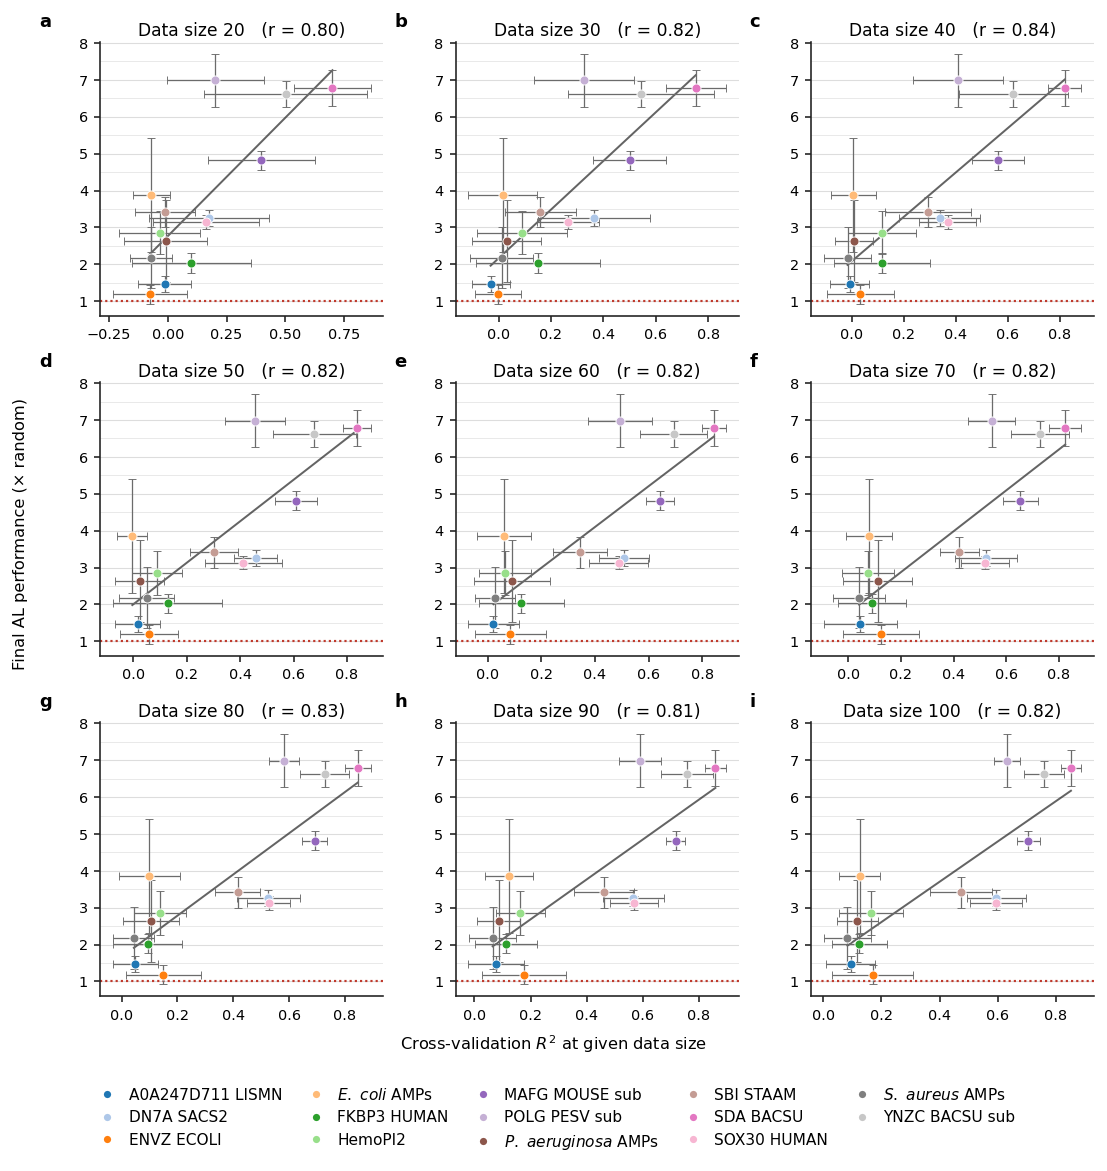

Saved cv_vs_endpoint_r2_physchem_greedy.png / .pdf


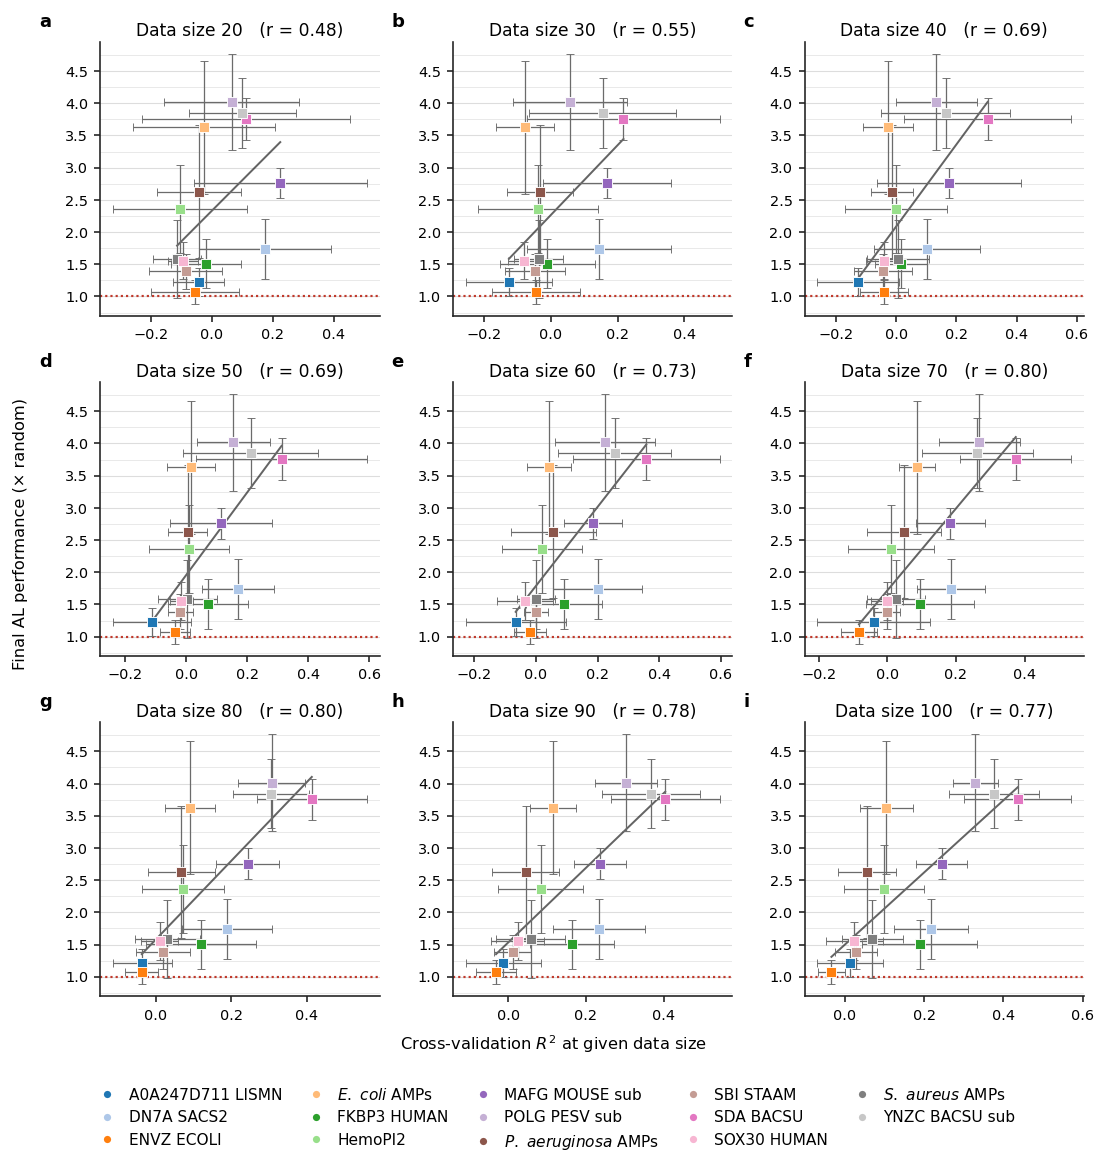

Saved cv_vs_endpoint_r2_morgan_greedy.png / .pdf


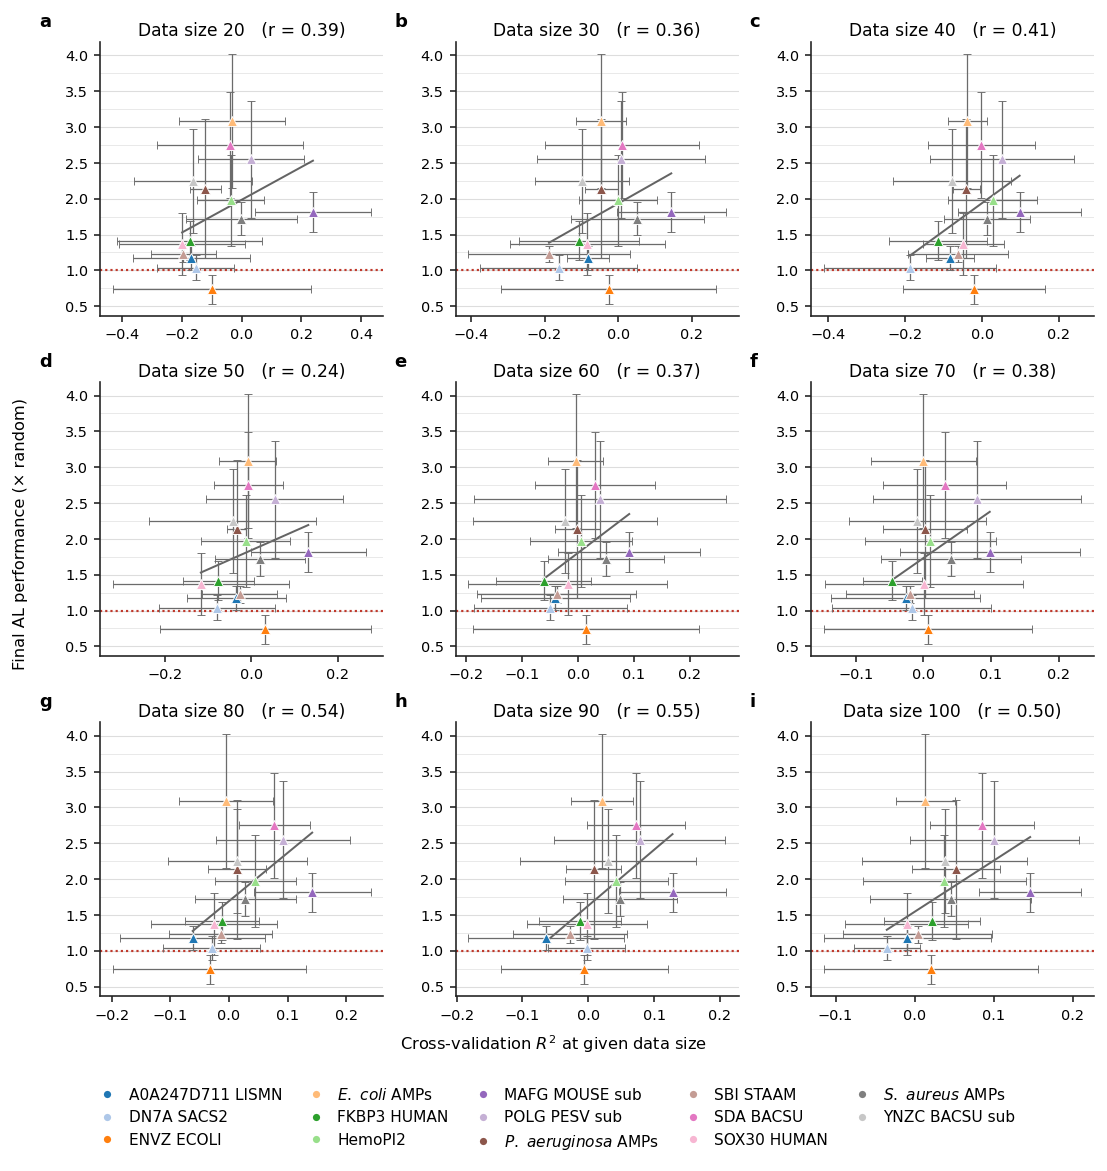

Saved cv_vs_endpoint_r2_n-gram_greedy.png / .pdf


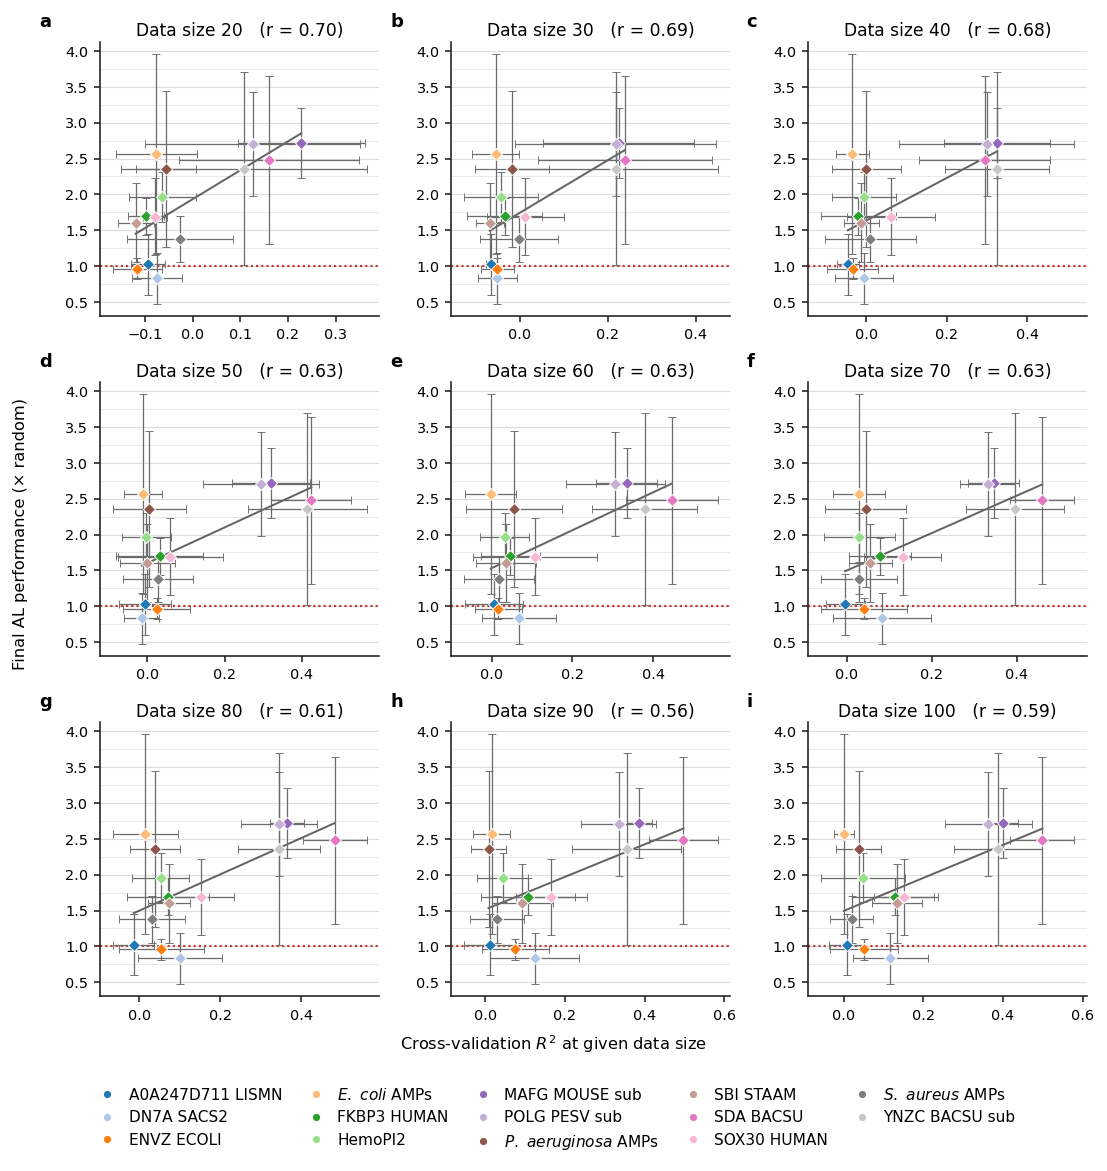

Saved cv_vs_endpoint_r2_scarse_mixed.png / .pdf


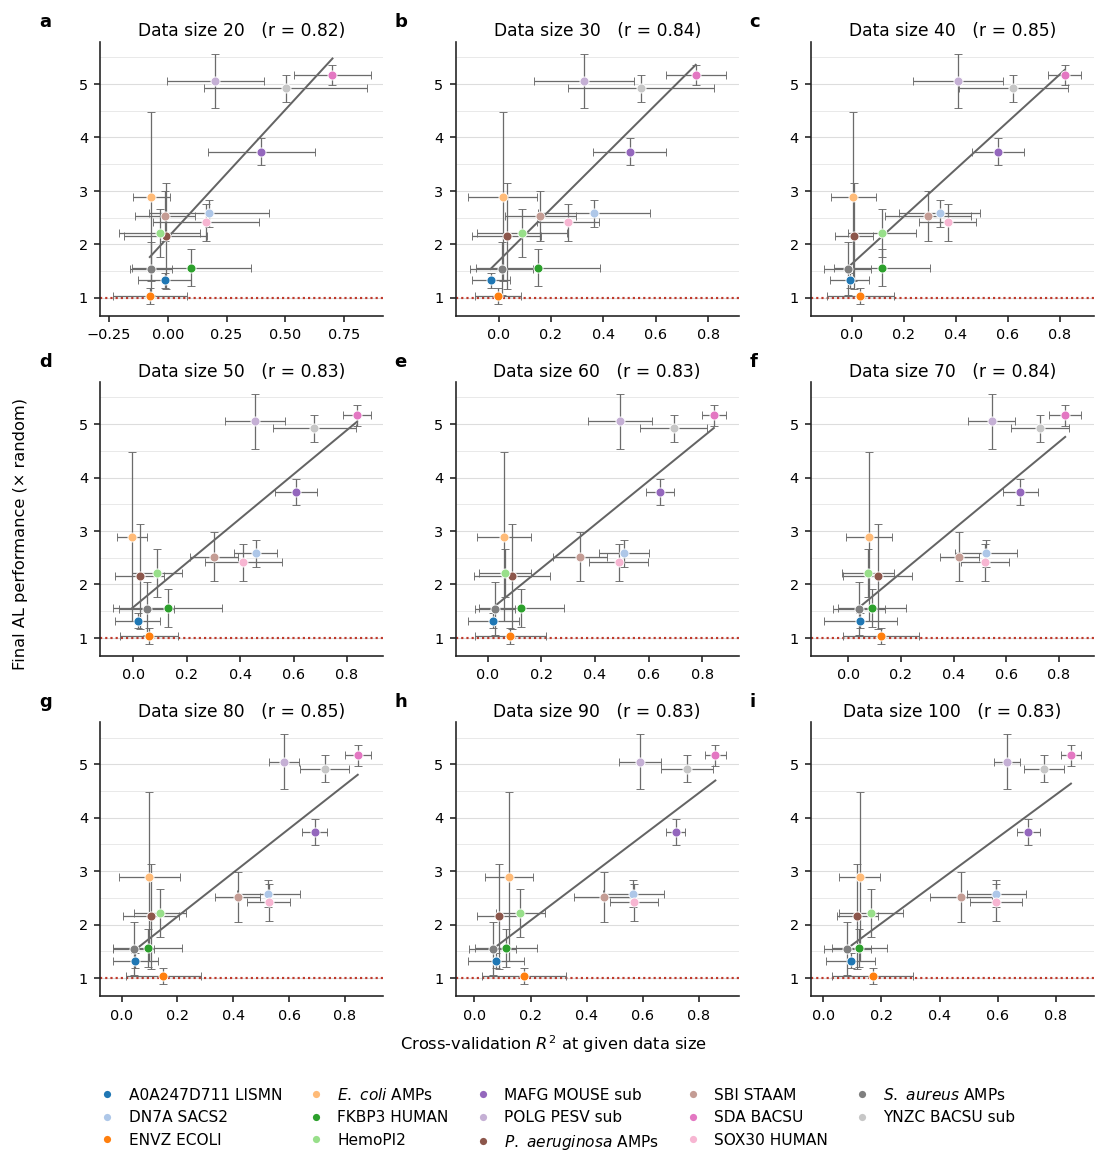

Saved cv_vs_endpoint_r2_physchem_mixed.png / .pdf


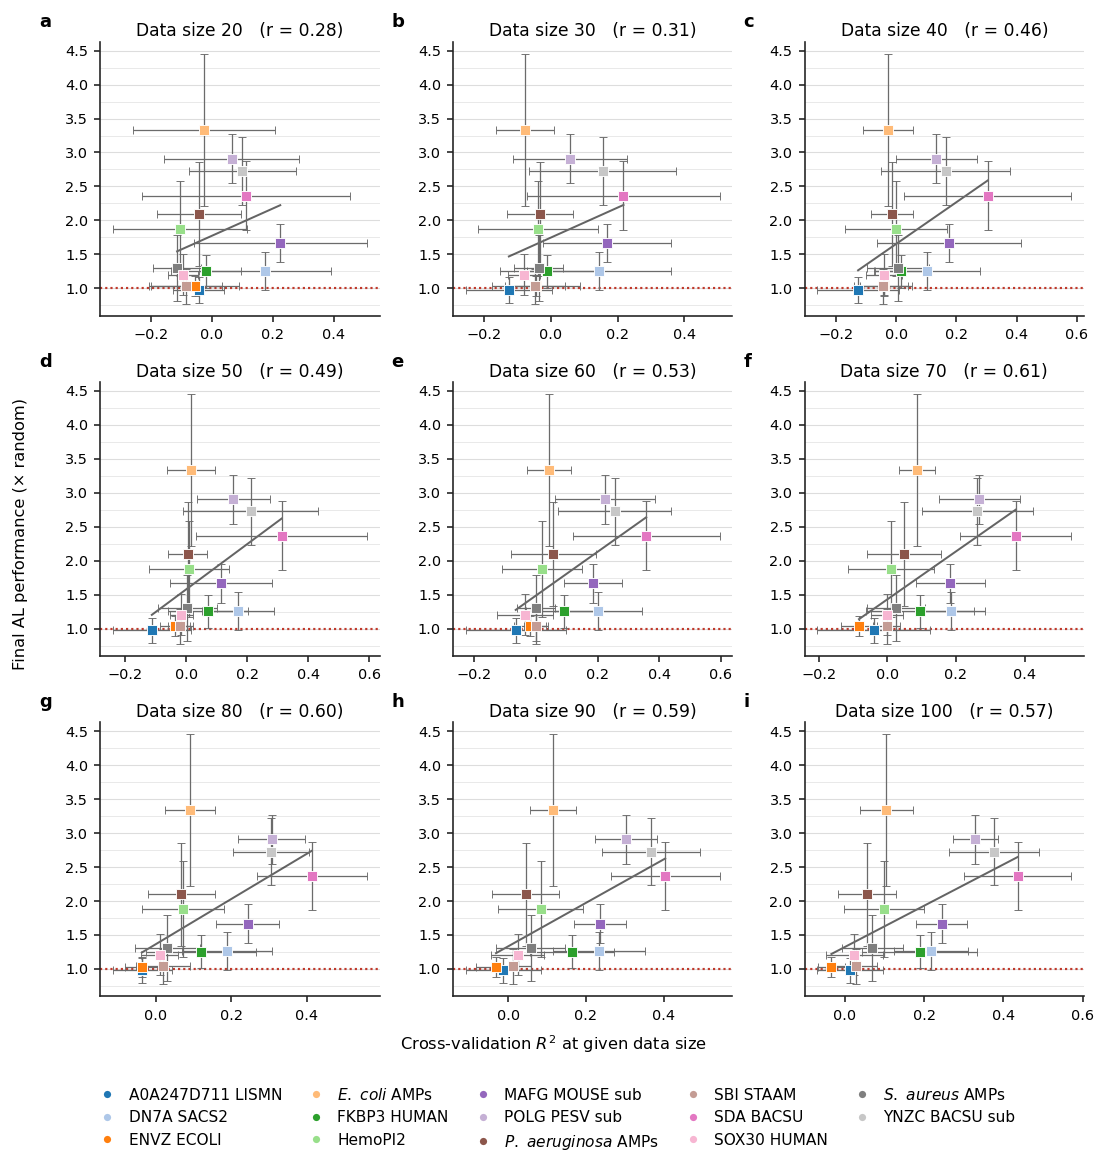

Saved cv_vs_endpoint_r2_morgan_mixed.png / .pdf


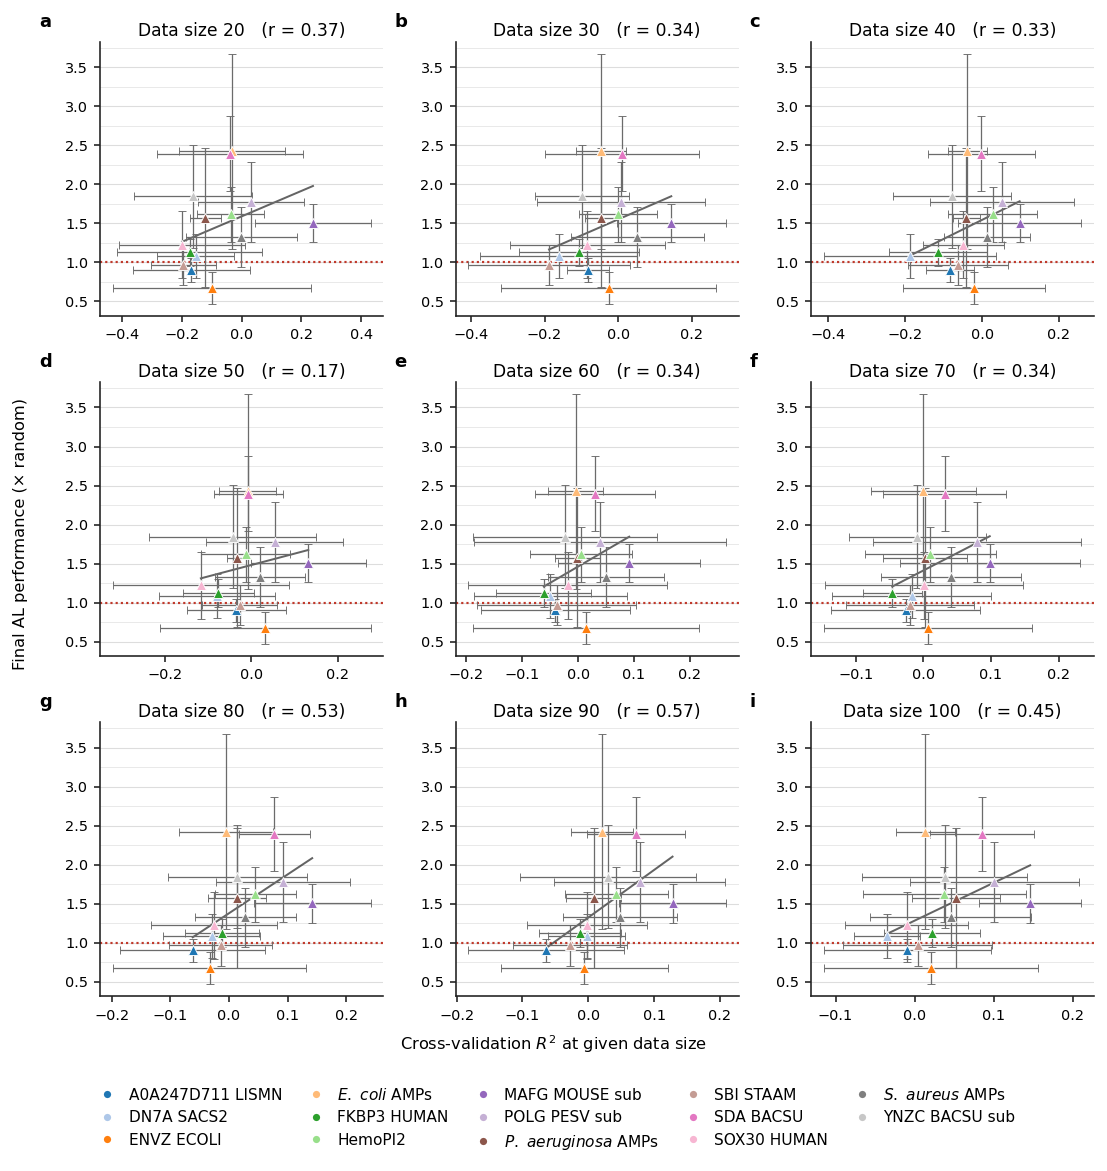

Saved cv_vs_endpoint_r2_n-gram_mixed.png / .pdf


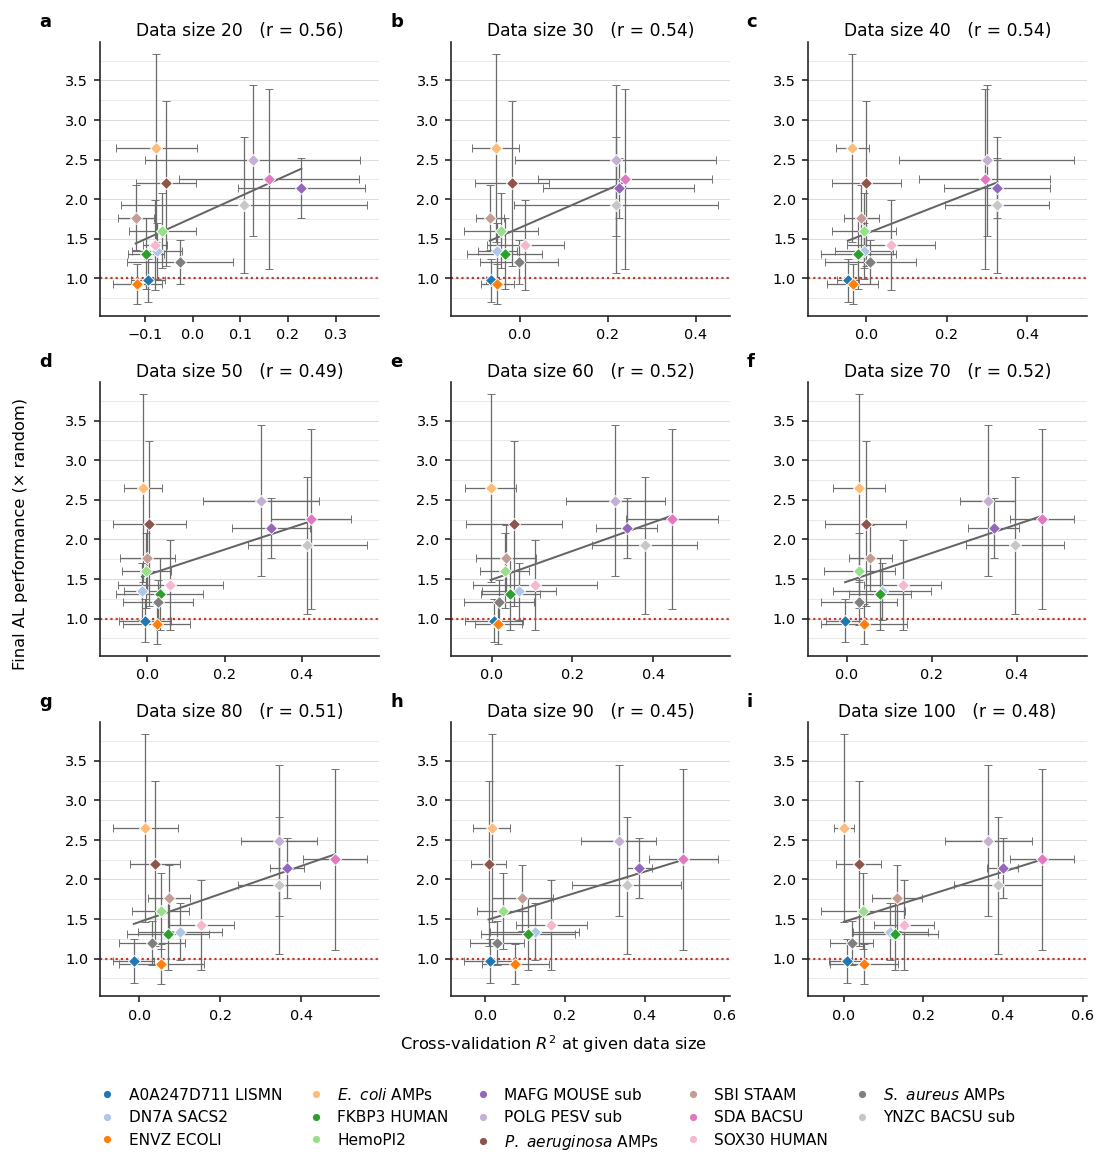

In [9]:
for acq in ACQUISITIONS:
    for model_label in REPRESENTATION_ORDER:
        _ = plot_cv_vs_endpoint("CV R2", model_label, acquisition=acq)

### CV Spearman ρ vs end-point performance, per representation and strategy

Saved cv_vs_endpoint_spearman_scarse_greedy.png / .pdf


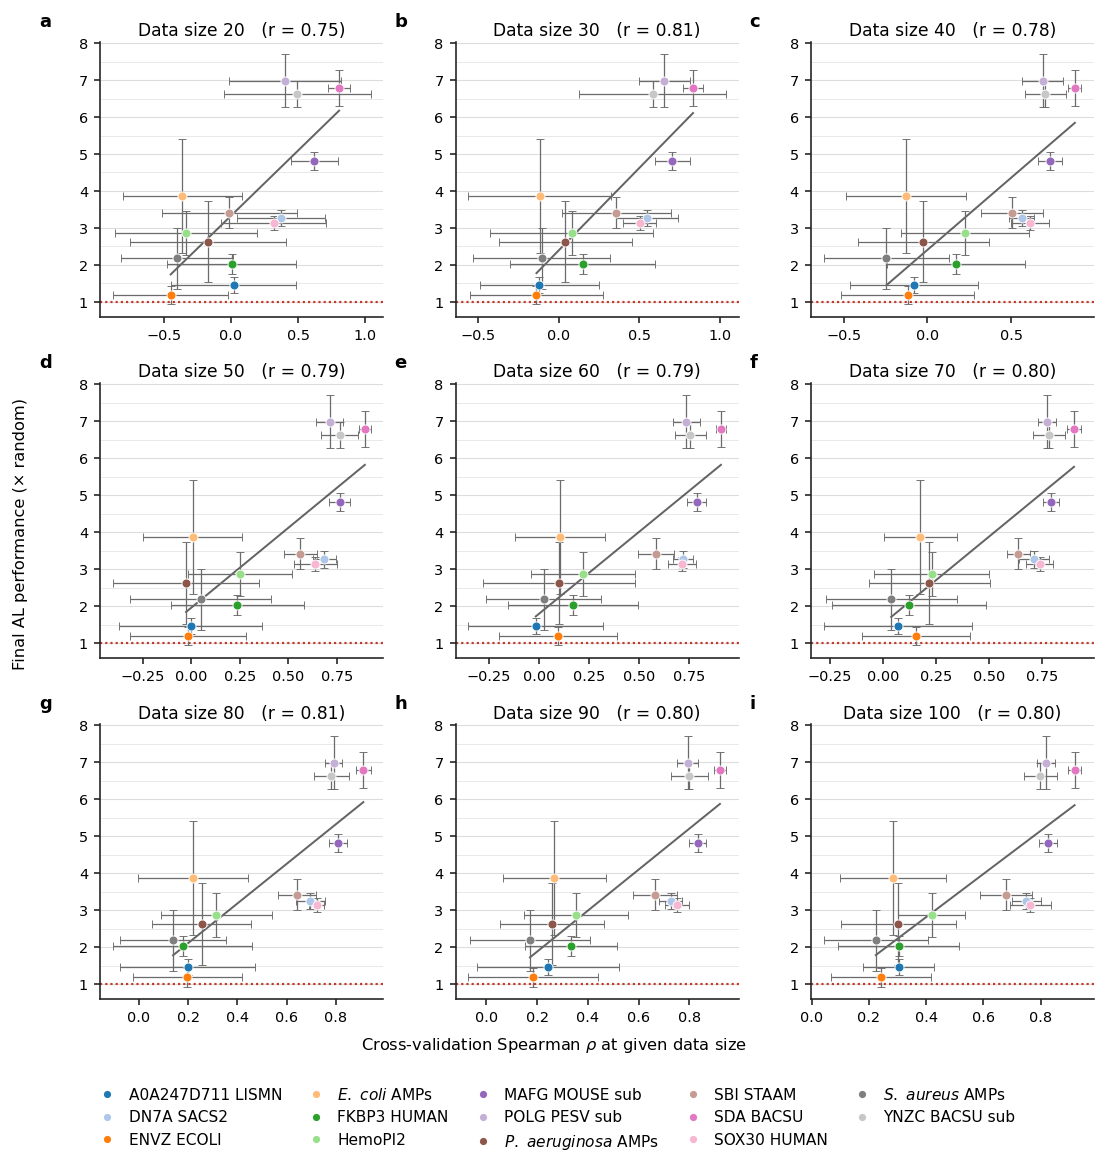

Saved cv_vs_endpoint_spearman_physchem_greedy.png / .pdf


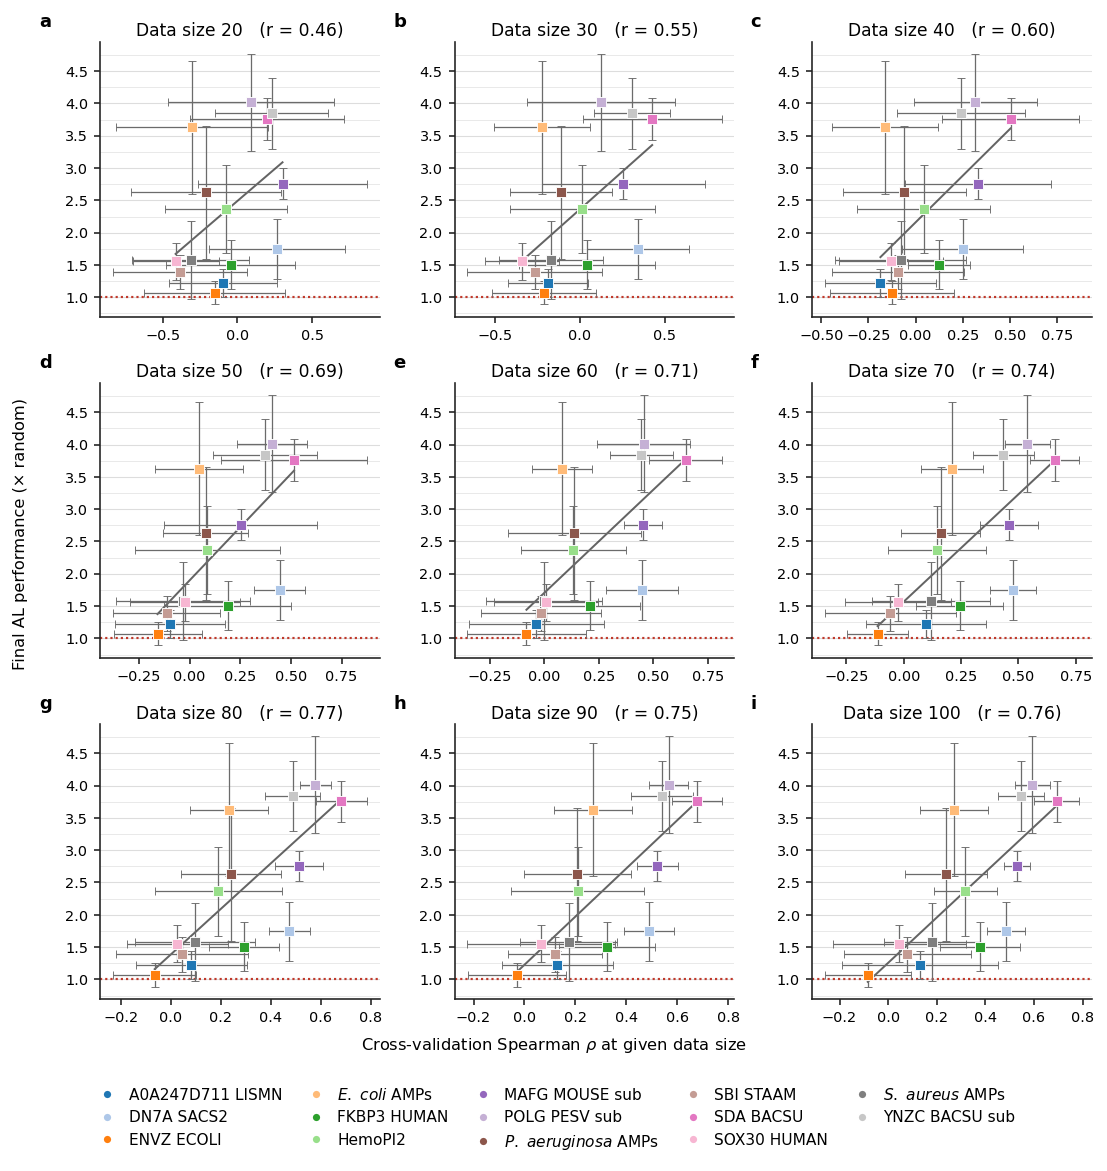

Saved cv_vs_endpoint_spearman_morgan_greedy.png / .pdf


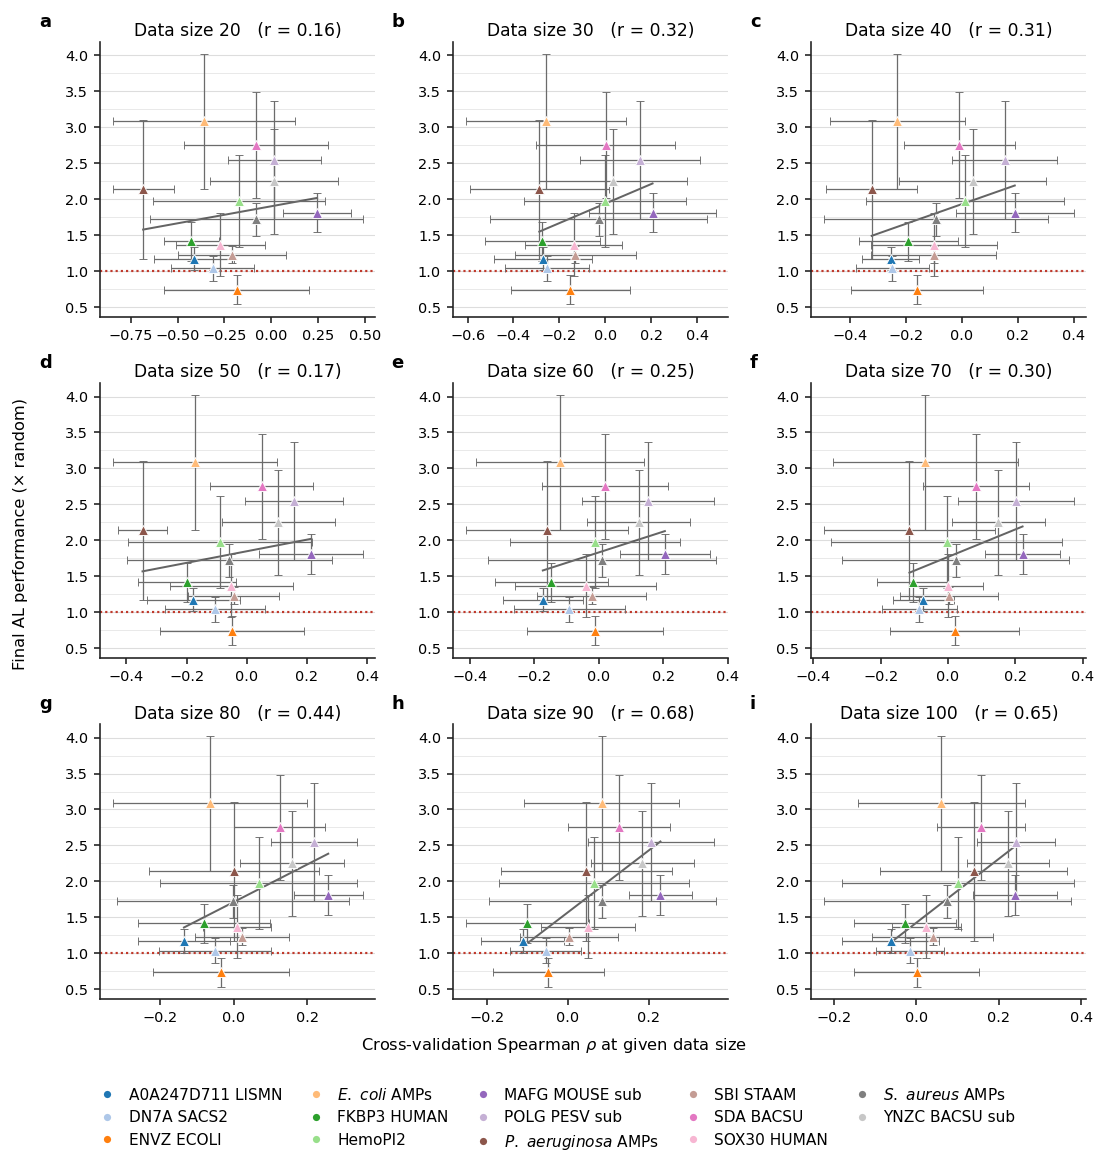

Saved cv_vs_endpoint_spearman_n-gram_greedy.png / .pdf


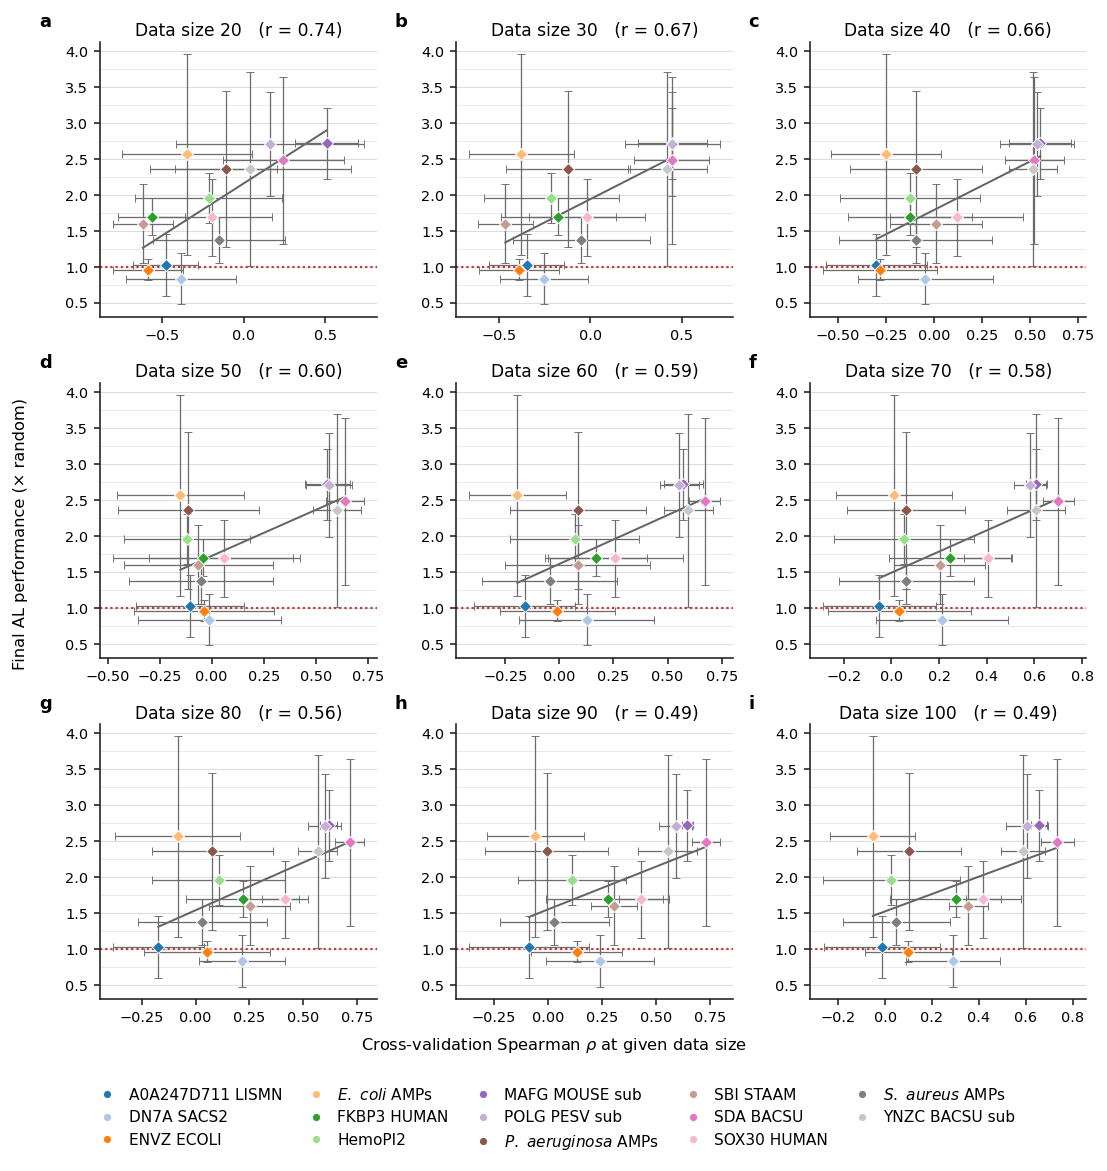

Saved cv_vs_endpoint_spearman_scarse_mixed.png / .pdf


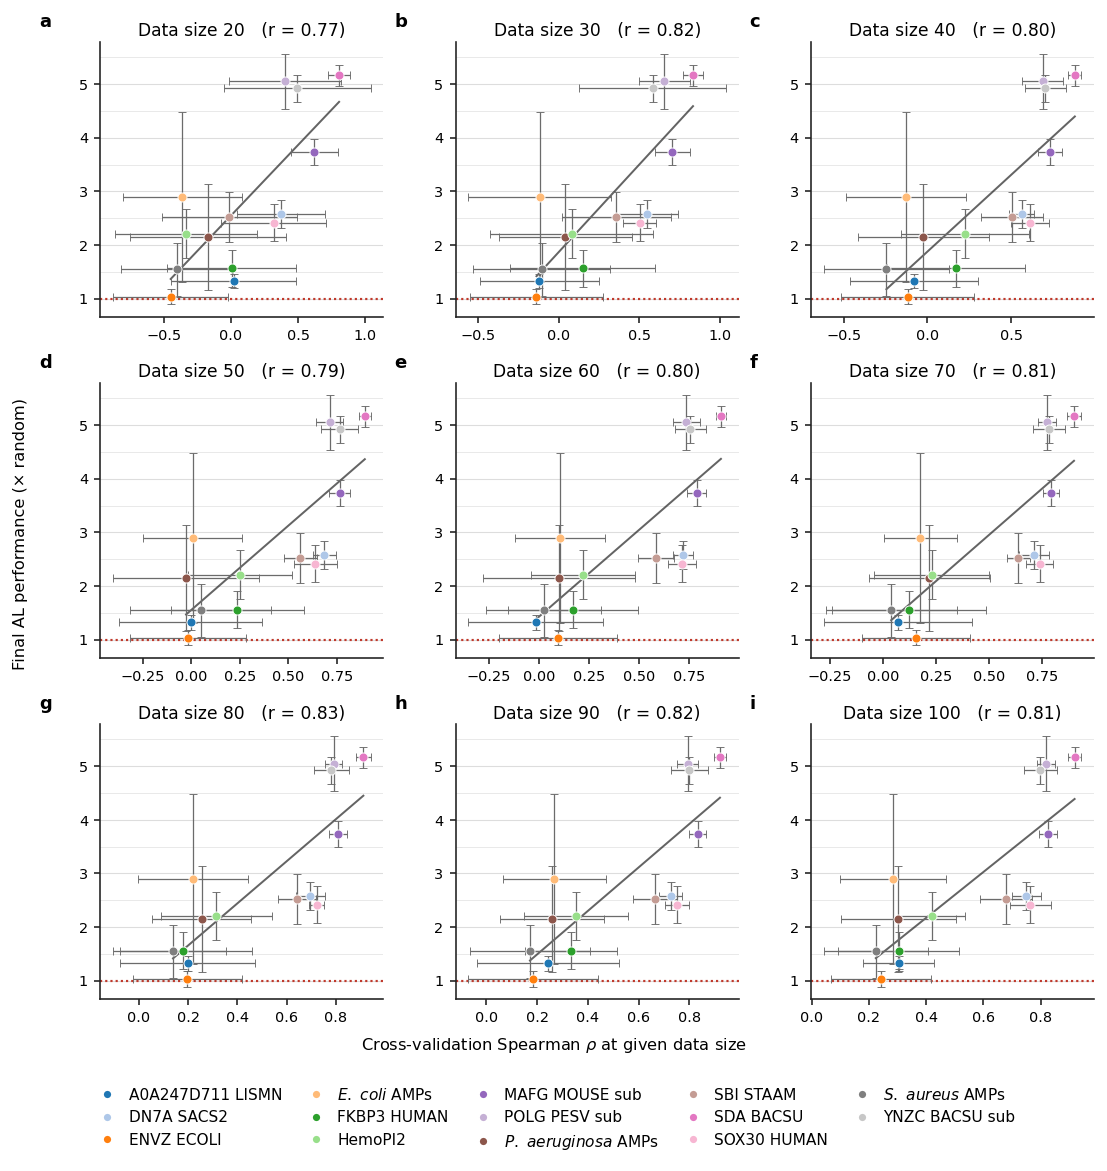

Saved cv_vs_endpoint_spearman_physchem_mixed.png / .pdf


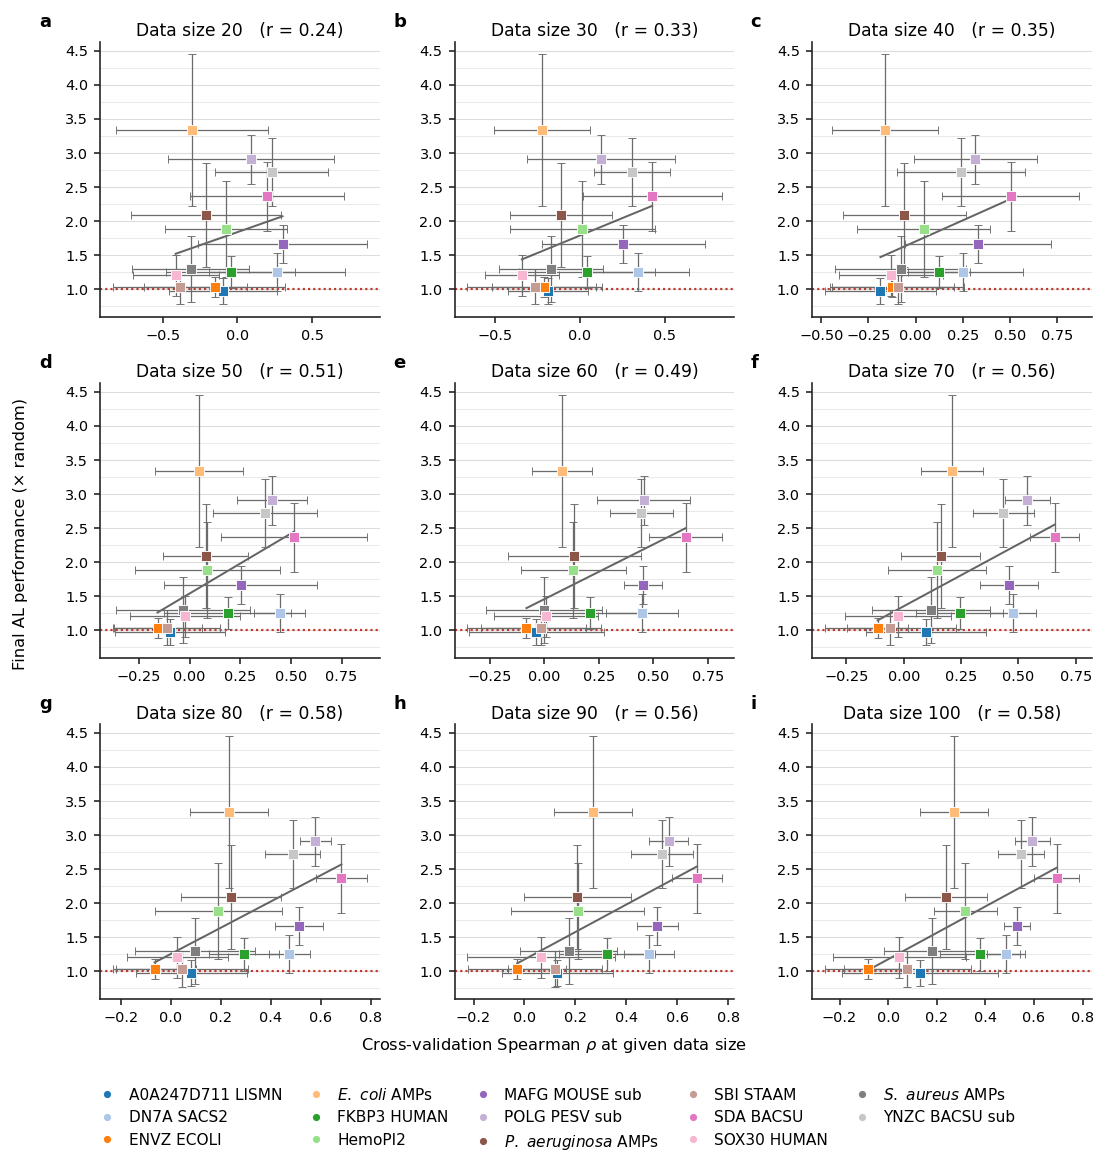

Saved cv_vs_endpoint_spearman_morgan_mixed.png / .pdf


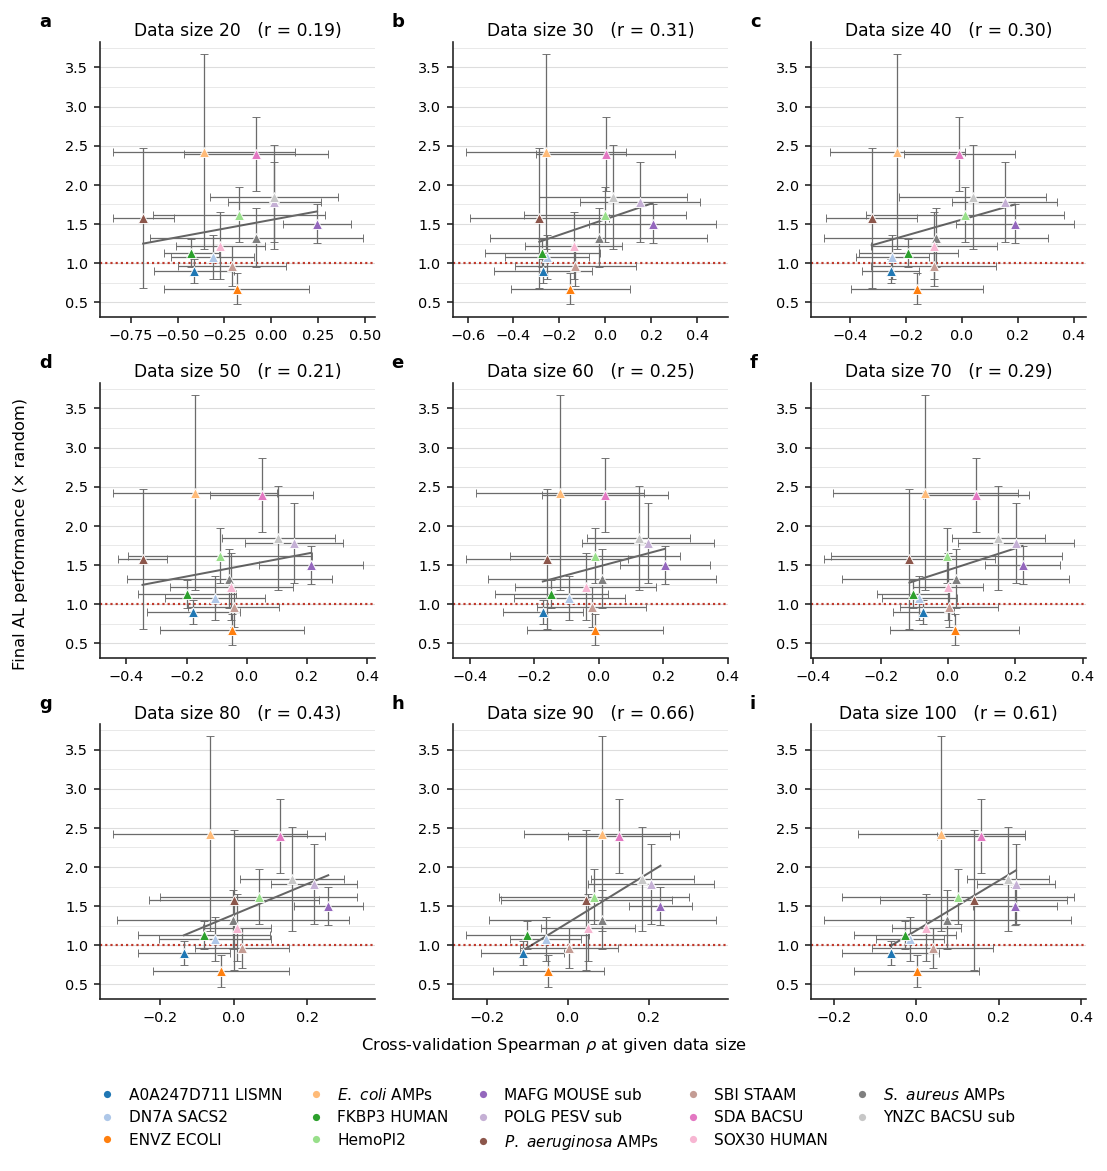

Saved cv_vs_endpoint_spearman_n-gram_mixed.png / .pdf


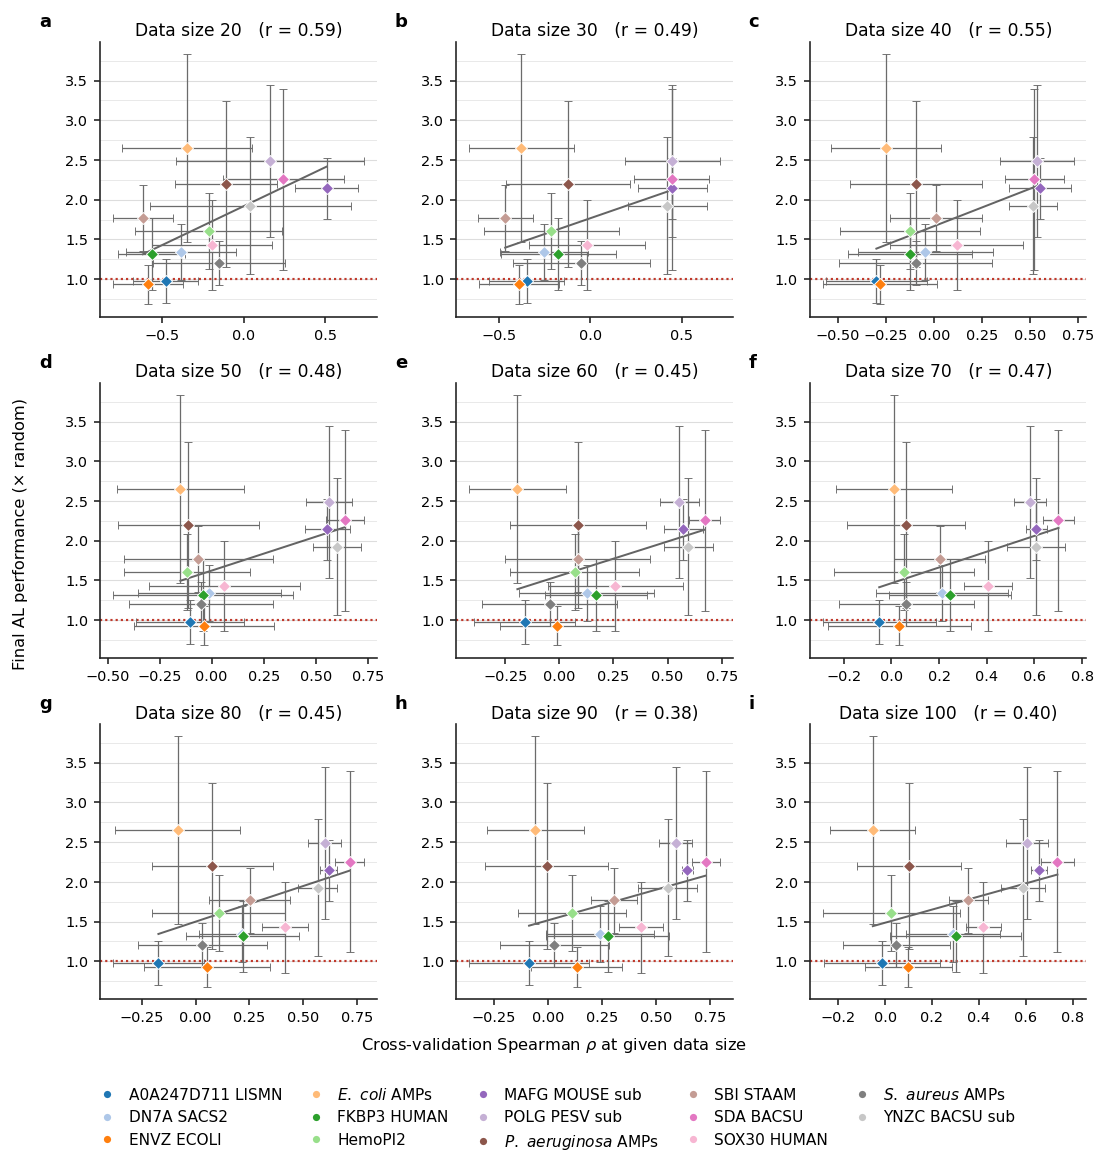

In [10]:
for acq in ACQUISITIONS:
    for model_label in REPRESENTATION_ORDER:
        _ = plot_cv_vs_endpoint("CV Spearman Correlation", model_label,
                                acquisition=acq)

## Active-learning results (combined figure)

One figure, mirroring the manuscript layout, for all four representations
(**SCARSE** and the three baselines):

* **a–g** — top-10% acquired (%) vs sequences screened: the mean over the
  substitution datasets, SCARSE's best and worst substitution dataset, then the
  four peptide datasets. Error bars are ±1 SD across seeds (across datasets for
  the mean panel), dodged in x; the black dotted line is random selection.
* **e (bottom left)** — the CV-vs-end-point *trajectory*: for SCARSE, each
  dataset's path as the training set grows, cross-validation R² (x) against
  active-learning end-point performance (y), faded early and dark at the largest
  data size.
* **f (bottom right)** — the mean across datasets of the per-dataset SD of CV R²,
  against data size: CV estimates get less noisy as the training set grows.

Produced twice: greedy only, and greedy + mixed together. Saved as
*active_learning_results.png* / *.pdf*.

Dropped 4 damaged row(s) of 47169; these come from tasks that appended to df_all.csv at the same moment.
SCARSE advantage over baselines (end point, greedy):
  best  POLG_PESV_sub  (+3.89 × random)
  worst ENVZ_ECOLI  (+0.26 × random)
Saved active_learning_results.png / .pdf


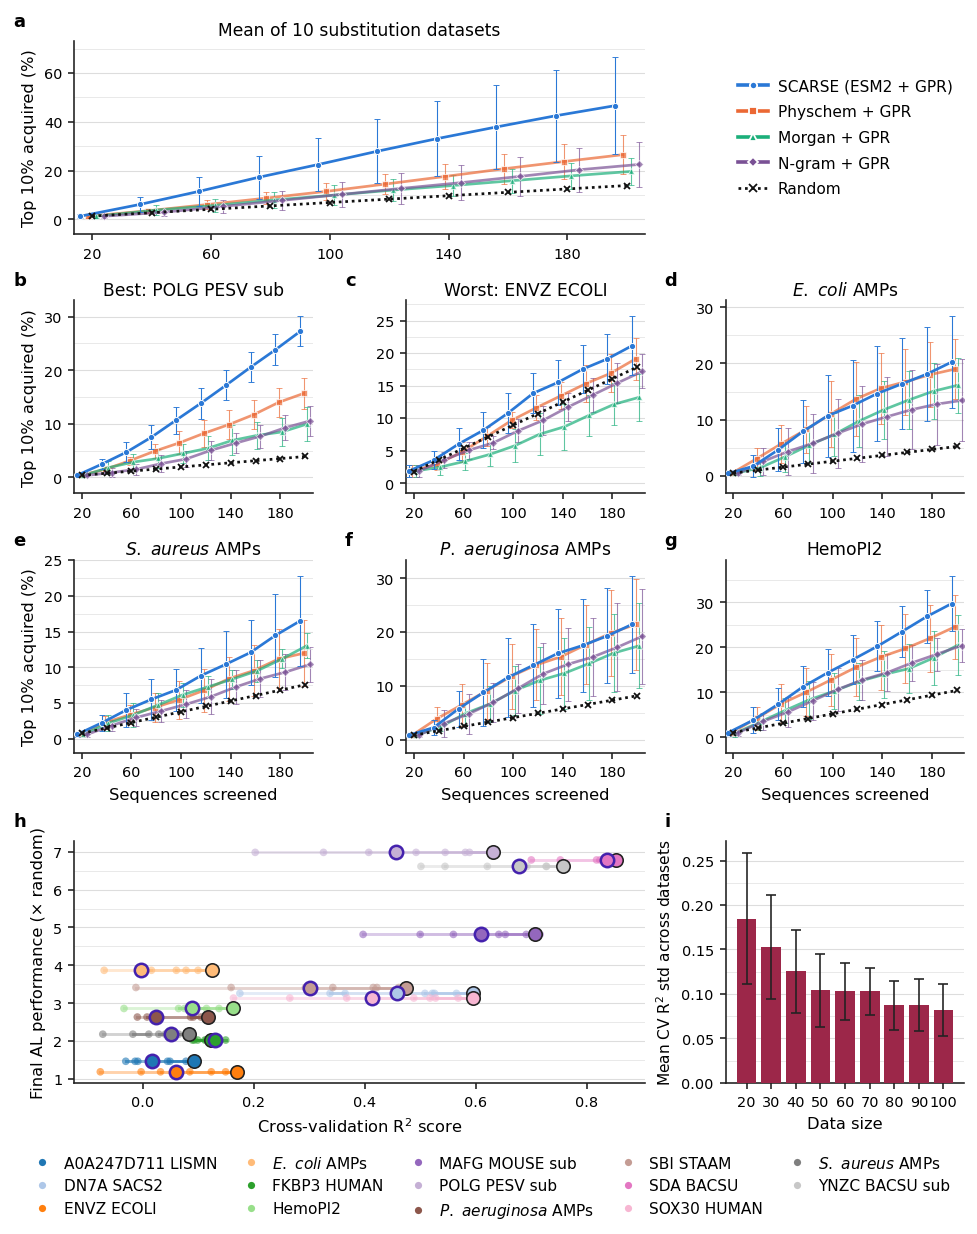

SCARSE advantage over baselines (end point, greedy):
  best  POLG_PESV_sub  (+3.89 × random)
  worst ENVZ_ECOLI  (+0.26 × random)
Saved active_learning_results_greedy_mixed.png / .pdf


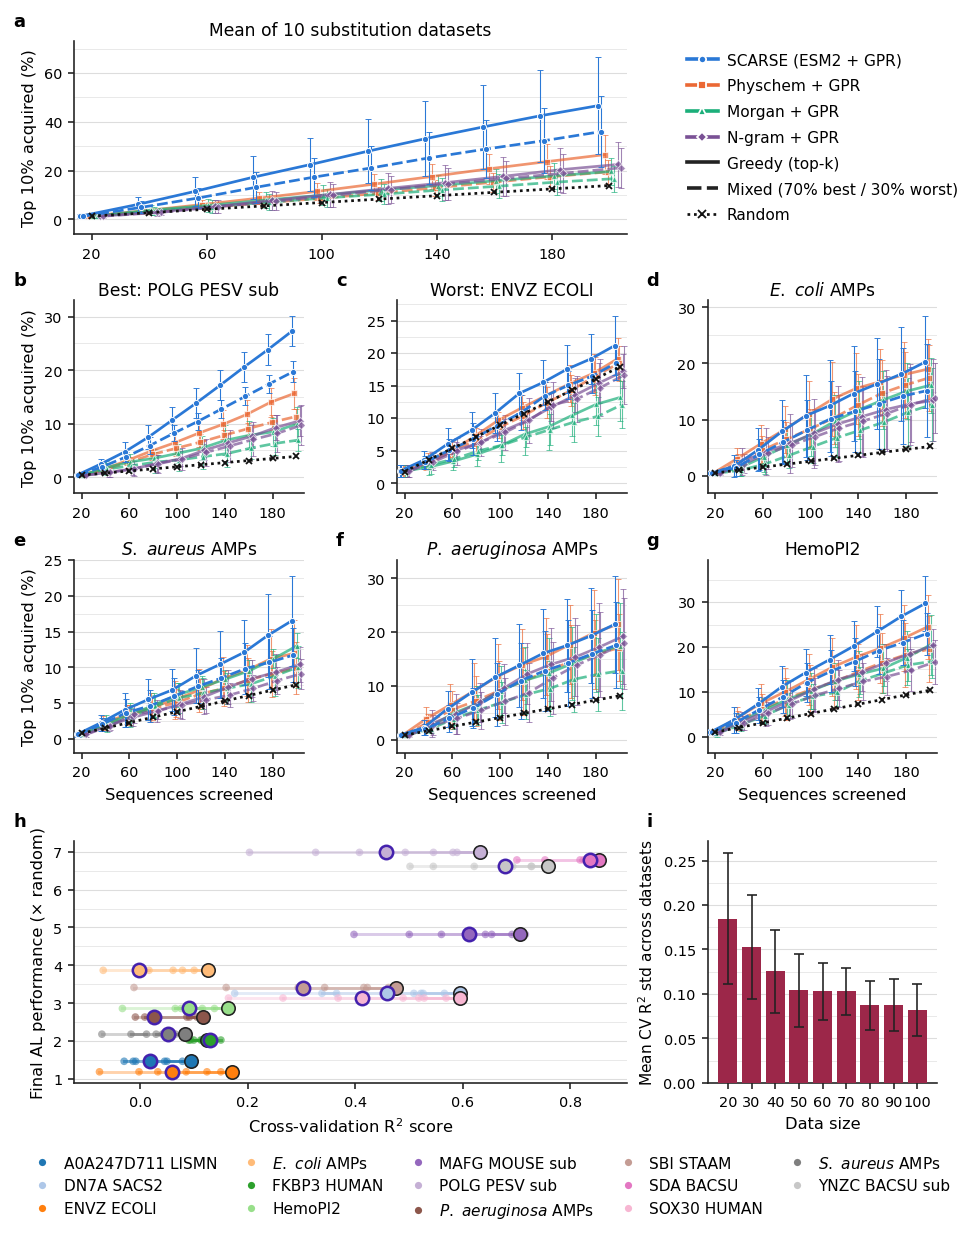

In [11]:
# Full acquisition curves (every screening step), separate from the end-point
# frame built above. load_results already dropped damaged rows.
_curve = load_results(WORKFLOW_RESULTS)
_curve = _curve[_curve["Metric"] == "Top 10% peptides selected (%)"]
_curve = _curve[_curve["Dataset"].isin(dataset_sizes)]
_curve["Model Label"] = _curve["Representation"].map(REPRESENTATION_LABELS)

SUB_DATASETS = [d for d in DATASETS
                if DATASETS[d][1].startswith("proteingym_dms/processed/substitutions")]
PEP_DATASETS = ["Ecoli_AMPs", "Saureus_AMPs", "Paeruginosa_AMPs", "HemoPI2"]
PEP_TITLE = {"Ecoli_AMPs": "E. coli AMPs", "Saureus_AMPs": "S. aureus AMPs",
             "Paeruginosa_AMPs": "P. aeruginosa AMPs", "HemoPI2": "HemoPI2"}

ACQ_STYLE = {"greedy": "-", "mixed": (0, (4, 1.5))}


def _curve_stats(df):
    """Mean and std across seeds per representation, strategy and screening step."""
    return (df.groupby(["Model Label", "Acquisition", "Num_samples"])["Value"]
              .agg(mean="mean", std="std").reset_index())


def _random_line(datasets):
    """(x, y%) random-selection reference, averaged over the given datasets."""
    xs = sorted(_curve["Num_samples"].unique())
    ys = [np.mean([n / dataset_sizes[d] * 100 for d in datasets]) for n in xs]
    return np.array(xs), np.array(ys)


def _draw_curve_panel(ax, stats, acqs, jitter, title, ylabel=None, random_datasets=None):
    order = [(m, a) for m in REPRESENTATION_ORDER for a in acqs]
    span = np.linspace(-4, 4, len(order)) if len(order) > 1 else [0.0]
    dodge = {k: off for k, off in zip(order, span)}
    for model in REPRESENTATION_ORDER:
        for acq in acqs:
            s = stats[(stats["Model Label"] == model) & (stats["Acquisition"] == acq)] \
                .sort_values("Num_samples")
            if s.empty:
                continue
            x = s["Num_samples"].values + (dodge[(model, acq)] if jitter else 0)
            # SCARSE sits in front at full opacity; the baselines are drawn behind
            # and slightly faded so the comparison lines stand out.
            is_scarse = model == REFERENCE_LABEL
            ax.errorbar(x, s["mean"].values, yerr=s["std"].values,
                        color=COLORS[model], linestyle=ACQ_STYLE[acq],
                        marker=MARKERS[model], markersize=3.4, markeredgecolor="white",
                        markeredgewidth=0.5, linewidth=1.5, capsize=1.6,
                        elinewidth=0.6, capthick=0.6,
                        zorder=5 if is_scarse else 3,
                        alpha=1.0 if is_scarse else 0.7)
    if random_datasets:
        xr, yr = _random_line(random_datasets)
        # random baseline in front of everything, full opacity
        ax.plot(xr, yr, color="#111111", linestyle=(0, (1, 1.4)), linewidth=1.5,
                marker="x", markersize=3.5, markeredgewidth=1.0, zorder=6)
    ax.set_title(title, pad=3)
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.margins(y=0.10)
    _finish_axis(ax)
    # x-ticks on real screening steps (20, 60, 100, 140, 180), with visible
    # tick marks on the axis so a reader can line a value up with the data.
    xs = sorted(_curve["Num_samples"].unique())
    ticks = [t for t in xs if (t - xs[0]) % 40 == 0]
    ax.set_xticks(ticks)
    ax.set_xlim(xs[0] - 6, xs[-1] + 6)
    ax.tick_params(axis="x", which="major", length=3.5, width=0.9,
                   direction="out", color=INK, bottom=True)


def _legend_handles(acqs):
    H = [plt.Line2D([0], [0], color=COLORS[m], marker=MARKERS[m], linewidth=2,
                    markersize=4, markeredgecolor="white", label=m)
         for m in REPRESENTATION_ORDER]
    if len(acqs) > 1:
        for a in acqs:
            H.append(plt.Line2D([0], [0], color=INK, linestyle=ACQ_STYLE[a],
                                linewidth=2, label=ACQUISITION_LABELS[a]))
    H.append(plt.Line2D([0], [0], color="#111111", linestyle=(0, (1, 1.4)),
                        marker="x", markersize=4, markeredgewidth=1.0, linewidth=1.5,
                        label="Random"))
    return H


#: Data size whose trajectory point is ringed in red (a reference training size).
HIGHLIGHT_SIZE = 50


def _draw_trajectory(ax, cv_metric="CV R2"):
    """Panel h: each dataset's path as data grows — CV score (x) vs SCARSE's AL
    end-point performance (y), faded early, dark at the largest data size. The
    point at HIGHLIGHT_SIZE gets a red ring."""
    d = df_merged[df_merged["Model Label"] == REFERENCE_LABEL]
    d = d[d["Acquisition"] == "greedy"]
    datasets = sorted(d["Dataset_base"].unique())
    palette = dataset_palette(datasets)
    xcol = f"{cv_metric} Mean"
    for ds in datasets:
        g = d[d["Dataset_base"] == ds].sort_values("Train Size")
        xs, ys = g[xcol].values, g["mean"].values
        sizes = g["Train Size"].values
        n = len(xs)
        if n == 0:
            continue
        a = np.linspace(0.25, 1.0, n)
        for i in range(n - 1):
            ax.plot(xs[i:i + 2], ys[i:i + 2], color=palette[ds], alpha=a[i + 1],
                    linewidth=1.6, zorder=2)
        # small faded dots for every data size except the two highlighted ones
        other = ~np.isin(sizes, [HIGHLIGHT_SIZE, sizes.max()])
        ax.scatter(xs[other], ys[other], color=palette[ds], alpha=0.6, s=18,
                   edgecolor="none", zorder=3)
        # largest data size: big filled marker, black edge (as before)
        m_final = sizes == sizes.max()
        ax.scatter(xs[m_final], ys[m_final], color=palette[ds], s=55,
                   edgecolor=INK, linewidth=0.9, zorder=4)
        # HIGHLIGHT_SIZE: the same big filled marker, with a red edge. No dataset
        # is red (see dataset_palette), so the red edge always reads as a ring.
        m_hl = sizes == HIGHLIGHT_SIZE
        if m_hl.any():
            ax.scatter(xs[m_hl], ys[m_hl], color=palette[ds], s=55,
                       edgecolor="#4421AD", linewidth=1.4, zorder=5)
    ax.set_xlabel(f"Cross-validation {'R$^2$' if 'R2' in cv_metric else chr(961)} score")
    ax.set_ylabel("Final AL performance (× random)")
    _finish_axis(ax)
    return datasets, palette


def _draw_std_bars(ax, cv_metric="CV R2"):
    """Panel f: mean across datasets of the per-dataset CV-score SD, per data size."""
    d = df_benchmark[df_benchmark["Model Label"] == REFERENCE_LABEL]
    scol = f"{cv_metric} Std"
    bar = (d.groupby("Train Size")[scol].agg(mean="mean", std="std")
           .reset_index().sort_values("Train Size"))
    xpos = np.arange(len(bar))
    ax.bar(xpos, bar["mean"].values, yerr=bar["std"].values, color="#9c2749",
           capsize=2.5, error_kw=dict(elinewidth=0.9, capthick=0.9, ecolor=INK),
           zorder=3)
    ax.set_xticks(xpos)
    ax.set_xticklabels([int(t) for t in bar["Train Size"]])
    ax.set_xlabel("Data size")
    ax.set_ylabel(f"Mean CV {'R$^2$' if 'R2' in cv_metric else chr(961)} std across datasets",
                  fontsize=8.5)
    _finish_axis(ax)


def plot_active_learning_results(acqs=("greedy",), stem="active_learning_results"):
    """One combined figure: substitutions mean / best / worst and the four peptide
    datasets (top), then the CV-vs-endpoint trajectory and the CV-noise bars (bottom).
    Mirrors the manuscript figure, with all four representations."""
    ylab = "Top 10% acquired (%)"
    # Best / worst = where SCARSE most and least outperforms the baselines at the
    # end point, i.e. SCARSE minus the mean baseline end-point performance. (Not
    # SCARSE's absolute score: a dataset where every method does well is not a
    # showcase of SCARSE.)
    e = df_workflow_stats[(df_workflow_stats["Acquisition"] == acqs[0])
                          & (df_workflow_stats["Dataset"].isin(SUB_DATASETS))]
    pivot = e.pivot_table(index="Dataset", columns="Model Label", values="mean")
    baselines = [m for m in REPRESENTATION_ORDER if m != REFERENCE_LABEL
                 and m in pivot.columns]
    advantage = (pivot[REFERENCE_LABEL] - pivot[baselines].mean(axis=1)).dropna()
    ranked = advantage.sort_values(ascending=False)
    best, worst = ranked.index[0], ranked.index[-1]
    print(f"SCARSE advantage over baselines (end point, {acqs[0]}):")
    print(f"  best  {best}  (+{ranked.iloc[0]:.2f} × random)")
    print(f"  worst {worst}  (+{ranked.iloc[-1]:.2f} × random)")

    fig = plt.figure(figsize=(7.4, 9.4), layout="constrained")
    # Row 0: the wide substitutions-mean panel (2 cols) + the legend (last col),
    # so no top cell is wasted. Row 1: best, worst, first peptide. Row 2: the
    # other three peptides. Row 3: trajectory (2 cols) + CV-noise bars.
    gs = fig.add_gridspec(4, 3, height_ratios=[1.0, 1.0, 1.0, 1.25])
    k = 0

    per_ds = (_curve[_curve["Dataset"].isin(SUB_DATASETS)]
              .groupby(["Model Label", "Acquisition", "Num_samples", "Dataset"])["Value"]
              .mean().reset_index())
    mean_stats = (per_ds.groupby(["Model Label", "Acquisition", "Num_samples"])["Value"]
                  .agg(mean="mean", std="std").reset_index())

    # a — substitutions mean, spanning the first two columns
    ax = fig.add_subplot(gs[0, 0:2])
    _draw_curve_panel(ax, mean_stats, acqs, jitter=True,
                      title=f"Mean of {len(SUB_DATASETS)} substitution datasets",
                      ylabel=ylab, random_datasets=SUB_DATASETS)
    _panel_letter(ax, k); k += 1

    # the representation / strategy legend fills the last cell of row 0
    lax = fig.add_subplot(gs[0, 2]); lax.axis("off")
    lax.legend(handles=_legend_handles(acqs), loc="center", frameon=False,
               ncol=1, handletextpad=0.6, labelspacing=0.7, fontsize=8.5)

    # b, c — SCARSE's best and worst substitution dataset; d — first peptide
    curve_panels = [("Best", best), ("Worst", worst)] +                    [(None, ds) for ds in PEP_DATASETS]
    for j, (tag, ds) in enumerate(curve_panels):
        row, col = 1 + (j // 3), j % 3
        ax = fig.add_subplot(gs[row, col])
        title = f"{tag}: {pretty_dataset(ds)}" if tag else pretty_dataset(ds)
        _draw_curve_panel(ax, _curve_stats(_curve[_curve["Dataset"] == ds]), acqs,
                          jitter=True, title=title,
                          ylabel=ylab if col == 0 else None, random_datasets=[ds])
        if row == 2:                              # bottom curve row
            ax.set_xlabel("Sequences screened")
        _panel_letter(ax, k); k += 1

    # bottom row: trajectory (h) spanning two columns, bars (i) in the last.
    # Their letters use the same placement as every other panel so the whole
    # figure's letters line up in a clean vertical column.
    ax_traj = fig.add_subplot(gs[3, 0:2])
    datasets, palette = _draw_trajectory(ax_traj)
    _panel_letter_inside(ax_traj, k); k += 1
    ax_bar = fig.add_subplot(gs[3, 2])
    _draw_std_bars(ax_bar)
    _panel_letter_inside(ax_bar, k); k += 1

    # dataset legend for the trajectory, under the bottom row
    dhandles = [plt.Line2D([0], [0], marker="o", linestyle="", markersize=5,
                           markerfacecolor=palette[ds], markeredgecolor="white",
                           label=pretty_dataset(ds)) for ds in datasets]
    fig.legend(handles=dhandles, loc="outside lower center",
               ncol=min(5, len(datasets)), frameon=False, handletextpad=0.4,
               columnspacing=1.2)
    _save(fig, stem)
    plt.show()
    return fig


_ = plot_active_learning_results(acqs=("greedy",), stem="active_learning_results")
_acqs_both = tuple(a for a in ACQUISITION_ORDER if a in ACQUISITIONS)
if len(_acqs_both) > 1:
    _ = plot_active_learning_results(acqs=_acqs_both,
                                     stem="active_learning_results_greedy_mixed")

## Which CV metric is the better predictor?

In [12]:
# ------------------------------------------------------------------
# Which CV metric tracks end-point performance better?
# ------------------------------------------------------------------
per_rep = df_results[df_results["Model Label"] != "All representations"]

comparison = (
    per_rep
    .pivot_table(index=["Acquisition", "Model Label", "Train Size"],
                 columns="CV Metric", values="Pearson r")
    .reset_index()
)

overall = (
    per_rep
    .groupby(["Acquisition", "CV Metric"])[["Pearson r", "Spearman rho"]]
    .agg(["mean", "std"])
    .round(3)
)

print("Correlation with end-point performance, averaged over representations "
      "and training sizes:\n")
print(overall.to_string())

for acq in ACQUISITIONS:
    best = (
        per_rep[per_rep["Acquisition"] == acq]
        .groupby("CV Metric")["Pearson r"].mean()
        .idxmax()
    )
    print(f"\n{ACQUISITION_LABELS[acq]}: the stronger predictor of end-point "
          f"performance is {best}")

print("\nPer representation and strategy (mean Pearson r across training sizes):\n")
print(
    per_rep
    .pivot_table(index=["Acquisition", "Model Label"], columns="CV Metric",
                 values="Pearson r")
    .reindex(pd.MultiIndex.from_product([ACQUISITIONS, REPRESENTATION_ORDER],
                                        names=["Acquisition", "Model Label"]))
    .round(3).to_string()
)

comparison.to_csv("results/cv_metric_comparison.csv", index=False)
print("\nWrote results/cv_metric_comparison.csv")
comparison.round(3).head(12)


Correlation with end-point performance, averaged over representations and training sizes:

                                    Pearson r        Spearman rho       
                                         mean    std         mean    std
Acquisition CV Metric                                                   
greedy      CV R2                       0.643  0.166        0.634  0.165
            CV Spearman Correlation     0.606  0.194        0.614  0.207
mixed       CV R2                       0.556  0.191        0.579  0.194
            CV Spearman Correlation     0.526  0.200        0.570  0.216

Greedy (top-k): the stronger predictor of end-point performance is CV R2

Mixed (70% best / 30% worst): the stronger predictor of end-point performance is CV R2

Per representation and strategy (mean Pearson r across training sizes):

CV Metric                        CV R2  CV Spearman Correlation
Acquisition Model Label                                        
greedy      SCARSE (ESM2 + GPR)  0

CV Metric,Acquisition,Model Label,Train Size,CV R2,CV Spearman Correlation
0,greedy,Morgan + GPR,20,0.394,0.158
1,greedy,Morgan + GPR,30,0.364,0.322
2,greedy,Morgan + GPR,40,0.408,0.306
3,greedy,Morgan + GPR,50,0.239,0.175
4,greedy,Morgan + GPR,60,0.366,0.245
5,greedy,Morgan + GPR,70,0.380,0.304
6,greedy,Morgan + GPR,80,0.545,0.440
7,greedy,Morgan + GPR,90,0.554,0.677
8,greedy,Morgan + GPR,100,0.498,0.651
9,greedy,N-gram + GPR,20,0.703,0.739
